In [1]:
#!echo $PYTHONPATH
!pip install ortools --target=/usr/local/lib/swan/nb_term_lib/

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 36.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 5.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 6.7 MB/s eta 0:00:00a 0:00:01
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
ERROR: pip's dependency resolver does not currently take into account all t

In [8]:
import sys
sys.path.append('..')
import os

import awkward as ak
import numpy as np
import uproot as uproot
import matplotlib.pyplot as plt
import mplhep as hep
import vector as vec
import matplotlib
from tqdm import tqdm

from Timing.plotting import *
from Timing.utils import *

from numba import prange, njit
import awkward.numba

plt.style.use(hep.style.CMS)
%matplotlib inline

In [9]:
def arr(x): 
    return np.asarray(x, dtype=float) 

In [10]:
@njit
def flatten_numba(a):
    return [x[0] if len(x) else 0 for x in a]

def dist(refEta, refPhi, otherTsEta, otherTsPhi):
    return ((otherTsEta-refEta)**2 + (otherTsPhi-refPhi)**2)**0.5

def distWrap2(refEta, refPhi, otherTsEta, otherTsPhi):
    deltaPhi = otherTsPhi - refPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    return ((otherTsEta - refEta) ** 2 + deltaPhi ** 2)

@njit
def distWrap2_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    deltaPhi = otherTsPhi - refPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    return ((otherTsEta - refEta) ** 2 + deltaPhi ** 2)

@njit
def dist_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        distance = ((otherTsEta[i] - refEta) ** 2 + (otherTsPhi[i] - refPhi) ** 2) ** 0.5
        out.append(distance)
    return np.array(out)

@njit
def distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi):
    out = []
    for i in range(len(otherTsEta)):
        deltaPhi = otherTsPhi[i] - refPhi
        deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
        distance = ((otherTsEta[i] - refEta) ** 2 + deltaPhi ** 2) ** 0.5
        out.append(distance)
    return np.array(out)
   
def find_track_id(array, number):
    try:
        return np.where(array == number)[0][0]
    except:
        return -1

In [11]:
def load_branch_with_highest_cycle(file, branch_name):
    # Get all keys in the file
    all_keys = file.keys()
    # Filter keys that match the specified branch name
    matching_keys = [key for key in all_keys if key.startswith(branch_name)]
    if not matching_keys:
        raise ValueError(f"No branch with name '{branch_name}' found in the file.")
    # Find the key with the highest cycle
    highest_cycle_key = max(matching_keys, key=lambda key: int(key.split(";")[1]))
    # Load the branch with the highest cycle
    branch = file[highest_cycle_key]
    return branch

In [12]:
C = 29.9792458 #cm/ns

def distance(x1,y1,z1,x2,y2,z2):
    return ((x1-x2)**2+(y1-y2)**2+(z1-z2)**2)**0.5

# returns res that contains the parameters, the chi squared and 
# the counts and bins used to plot the data
def gauss_fit(data, init_parms, bins=300):
    hist, nbins = np.histogram(data, bins=bins)
    nbins = 0.5 * (bins[1:] + bins[:-1])
    errors = [np.sqrt(oh+1) for oh in hist]
    init_parameters = init_parms
    cost_func = cost.LeastSquares(nbins, hist, errors, model)
    min_obj = Minuit(cost_func, *init_parameters)
    res = min_obj.migrad()
    chi2 = min_obj.fval/(len(nbins[:-1])-3)
    return res, chi2, hist, nbins[:-1]

#same as above but plots also the data
def gauss_fit_and_plot(data, init_parms, label="data", colors=["midnightblue","dodgerblue"], bins=300):
    res, chi2, hists, newbins = gauss_fit(data, init_parms, bins=bins)
    y = model(newbins, *res.values)
    plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], linewidth=2)
    plt.hist(np.array(data), bins=bins, color=colors[1], alpha=0.7)
    plt.legend(fontsize=16)
    plt.grid()
    return res, chi2

# quick plot with list, np array or flattened awkward array
def myhist(X, bins=30, title='title', xlabel='time (ns)', ylabel='Counts / bin', color='dodgerblue', alpha=1, fill='stepfilled', range=None, label="data"):
    #plt.figure(dpi=100)
    if range==None:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, label=label)
    else:
        plt.hist(np.array(X), bins=bins, color=color, alpha=alpha, histtype=fill, range=range, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid()  

<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_439/3869421007.py:23: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], linewidth=2)
/tmp/ipykernel_439/3869421007.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(newbins, y, label=f'gauss fit\n   $\sigma$ = {res.values[2]:.3f} $\pm$ {res.errors[2]:.3f}\n   $x_0$ = {res.values[1]:.3f} $\pm$ {res.errors[1]:.3f} \n   $\chi^2_0$ = {chi2:.3f}', color=colors[0], l

In [13]:
tracksKeys = [
 'track_id',
 'track_hgcal_x',
 'track_hgcal_y',
 'track_hgcal_z',
 'track_hgcal_eta',
 'track_hgcal_phi',
 'track_hgcal_pt',
 'track_pt',
 'track_p',
 'track_missing_outer_hits',
 'track_missing_inner_hits',
 'track_quality',
#  'track_charge',
#  'track_time',
#  'track_time_quality',
#  'track_time_err',
#  'track_beta',
 'track_time_mtd',
 'track_time_mtd_err',
#  'track_pos_mtd',
 'track_pos_mtd/track_pos_mtd.theVector.theX',
 'track_pos_mtd/track_pos_mtd.theVector.theY',
 'track_pos_mtd/track_pos_mtd.theVector.theZ',
 'track_nhits',
 'track_isMuon',
 'track_isTrackerMuon'
]

simTsKeys = [
 'regressed_energy',
 'raw_energy',
 'trackIdx',
 # 'raw_em_energy',
 # 'raw_pt',
 # 'raw_em_pt',
 'barycenter_x',
 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
'time',
 'timeError',
 #'trackTime',
 # 'EV1',
 # 'EV2',
 # 'EV3',
 # 'eVector0_x',
 # 'eVector0_y',
 # 'eVector0_z',
 # 'sigmaPCA1',
 # 'sigmaPCA2',
 # 'sigmaPCA3',
 # 'regressed_pt',
 'CPidx',
 'pdgID',
 'vertices_indexes',
 'vertices_x',
 'vertices_y',
 'vertices_z',
 'vertices_time',
#  'vertices_timeErr',
 'vertices_energy',
 'vertices_multiplicity'
]

assKeys = [
 'ticlTracksterLinks_recoToSim_SC',
 'ticlTracksterLinks_recoToSim_SC_score',
 'ticlTracksterLinks_recoToSim_SC_sharedE',
 'ticlTracksterLinks_simToReco_SC',
 'ticlTracksterLinks_simToReco_SC_score',
 'ticlTracksterLinks_simToReco_SC_sharedE',
#     'ticlCandidate_simToReco_CP_score',
#     'ticlCandidate_simToReco_CP_sharedE'
 'ticlCandidate_simToReco_SC',
 'ticlCandidate_simToReco_SC_score',
 'ticlCandidate_simToReco_SC_sharedE',
 'ticlCandidate_recoToSim_SC',
 'ticlCandidate_recoToSim_SC_score',
 'ticlCandidate_recoToSim_SC_sharedE',
 'ticlTracksterLinks_simToReco_CP',
 'ticlTracksterLinks_simToReco_CP_score',
 'ticlTracksterLinks_simToReco_CP_sharedE',
          ]

tsKeys = [
#  'NTracksters',
#  'NClusters',
 'time',
 'timeError',
 'regressed_energy',
 'raw_energy',
 'raw_em_energy',
 'raw_pt',
 'raw_em_pt',
 'barycenter_x',
 'barycenter_y',
 'barycenter_z',
 'barycenter_eta',
 'barycenter_phi',
#  'EV1',
#  'EV2',
#  'EV3',
#  'eVector0_x',
#  'eVector0_y',
#  'eVector0_z',
#  'sigmaPCA1',
#  'sigmaPCA2',
#  'sigmaPCA3',
#  'id_probabilities',
#  'vertices_indexes',
 'vertices_x',
 'vertices_y',
 'vertices_z',
#  'vertices_time',
#  'vertices_timeErr',
 'vertices_energy',
#  'vertices_correctedEnergy',
#  'vertices_correctedEnergyUncertainty',
#  'vertices_multiplicity'
]

In [14]:
simcandkeys = [
 'simTICLCandidate_raw_energy',
 'simTICLCandidate_regressed_energy',
 'simTICLCandidate_simTracksterCPIndex',
 # 'simTICLCandidate_boundaryX',
 # 'simTICLCandidate_boundaryY',
 # 'simTICLCandidate_boundaryZ',
 # 'simTICLCandidate_boundaryPx',
 # 'simTICLCandidate_boundaryPy',
 # 'simTICLCandidate_boundaryPz',
 # 'simTICLCandidate_time',
 # 'simTICLCandidate_caloParticleMass',
 'simTICLCandidate_pdgId',
 # 'simTICLCandidate_charge',
 'simTICLCandidate_tracks_in_candidate']

candkeys = [
 # 'NCandidates',
 'candidate_charge',
 'candidate_pdgId',
 'candidate_id_probabilities',
 'candidate_time',
 'candidate_timeErr',
 'candidate_energy',
 'candidate_raw_energy',
 # 'candidate_px',
 # 'candidate_py',
 # 'candidate_pz',
 'track_in_candidate',
 'tracksters_in_candidate']

## read file

In [15]:
import os
print(os.listdir("../SampleProduction/TICLv5/TTbarPU/"))

['histo', 'step2']


In [16]:
PT = 100
ETA =1.7

In [17]:
label = "pt"+str(PT)+"_eta"+str(ETA).replace(".", "p")
PU = "_Pi_"+label+"_200"
# file = uproot.open("TTbar_PU200_1500pre1.root")
file = uproot.open("/eos/user/a/aperego/Timing/root_files/multiParticleInConePt1to100.root") # SampleProduction/TICLv5/ParticleGunPionPU/histo_"+label+"/histo_"+label+".root") # /eos/user/a/aperego/Timing/tsTime/histoNMIN1Sigma3.root") #SinglePi_PU_"+label+".root")


In [18]:
file.keys()

['ticlDumper;1',
 'ticlDumper/ticlTrackstersCLUE3DHigh;1',
 'ticlDumper/ticlTracksterLinks;1',
 'ticlDumper/ticlCandidate;1',
 'ticlDumper/ticlTracksterLinksSuperclusteringDNN;1',
 'ticlDumper/simtrackstersSC;1',
 'ticlDumper/simtrackstersCP;1',
 'ticlDumper/clusters;1',
 'ticlDumper/candidates;1',
 'ticlDumper/superclustering;1',
 'ticlDumper/associations;1',
 'ticlDumper/tracks;1',
 'ticlDumper/simTICLCandidate;1']

In [19]:
alltracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlTrackstersCLUE3DHigh')
allsimtrackstersCP = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersCP')
allsimtrackstersSC = load_branch_with_highest_cycle(file, 'ticlDumper/simtrackstersSC')
allassociations = load_branch_with_highest_cycle(file, 'ticlDumper/associations')
alltracks = load_branch_with_highest_cycle(file, 'ticlDumper/tracks')
allticlTracksterLinks = load_branch_with_highest_cycle(file, 'ticlDumper/ticlTracksterLinks')

simtrackstersCP = allsimtrackstersCP.arrays(simTsKeys)
simtrackstersSC = allsimtrackstersSC.arrays(simTsKeys)
# tracksters = alltracksters.arrays(tsKeys)
associations = allassociations.arrays(assKeys)
tracks = alltracks.arrays(tracksKeys)
tracksterLinks = allticlTracksterLinks.arrays(tsKeys)

In [20]:
# allSimTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/simTICLCandidate')
# simTICLCandidate = allSimTICLCandidates.arrays(simcandkeys)
allTICLCandidates = load_branch_with_highest_cycle(file,'ticlDumper/candidates')
candidates = allTICLCandidates.arrays(candkeys)
allTICLCandidatesTracksters = load_branch_with_highest_cycle(file,'ticlDumper/ticlCandidate')
candTracksters = allTICLCandidatesTracksters.arrays(tsKeys)

In [15]:
tracks_p = tracks.track_p
tracks_time = tracks.track_time_mtd
tracks_timeErr = tracks.track_time_mtd_err
tracks_MTDposX = tracks['track_pos_mtd/track_pos_mtd.theVector.theX']
tracks_MTDposY = tracks['track_pos_mtd/track_pos_mtd.theVector.theY']
tracks_MTDposZ = tracks['track_pos_mtd/track_pos_mtd.theVector.theZ']

## scores

In [16]:
def find_track_ids(array, numbers):
    # Create a dictionary mapping values to indices
    index_map = {val: idx for idx, val in enumerate(array)}
    # Use vectorized lookup, returning -1 if number is not found
    return np.array([index_map.get(num, -1) for num in numbers])

@njit
def find_in_array_with_none(array, match):
    for i, el in enumerate(array):
        if len(el) == 0: continue
        if el[0] == match:
            return i
    return -1

In [17]:
C_CM_PER_NS = 29.9792458

In [100]:
rEp_ass_all = []
rEp_other_all = []

dR_ass_all = []
dR_other_all = []

delta_t_ass_all = []
delta_t_other_all = []

allNeutral_dR_ass = []
allNeutral_dR_other = []

# allNeutral_en_ass = []
# allNeutral_en_other = []
# allNeutral_eta_ass = []
# allNeutral_eta_other = []

all_charged_score_ass = []
all_charged_score_oth = []

for ev in tqdm(prange(100)): #len(simtrackstersSC))):
    stsSCEv = simtrackstersSC[ev]
    tracksEv = tracks[ev]
    tsTime = stsSCEv.time
    tsTimeError = stsSCEv.timeError
    ts_x = stsSCEv.barycenter_x
    ts_y = stsSCEv.barycenter_y
    ts_z = stsSCEv.barycenter_z
    allTsEta = stsSCEv.barycenter_eta
    allTsPhi = stsSCEv.barycenter_phi

    for idx in prange(len(stsSCEv.trackIdx)):
        refTsEta = stsSCEv.barycenter_eta[idx]
        refTsPhi = stsSCEv.barycenter_phi[idx]
        refTsEnergy = stsSCEv.raw_energy[idx]
        
        sameSide = allTsEta * stsSCEv.barycenter_eta[idx] > 0
        closeMask = distWrap2(refTsEta, refTsPhi, allTsEta, allTsPhi) < 0.2**2
        other_mask = np.asarray(sameSide & closeMask)
        other_mask[idx] = 0
        
        if not(len(other_mask)): continue # nothing to do
        
        otherTsEta = allTsEta[other_mask]
        otherTsPhi = allTsPhi[other_mask]
        otherTsZ = stsSCEv.barycenter_z[other_mask]
        otherTsEnergy = stsSCEv.raw_energy[other_mask]
        
        # find track position in the tracks array using track index
        trk_id = find_track_id(tracksEv.track_id, stsSCEv.trackIdx[idx]) 
        if trk_id == -1:
            ## neutral tracksters
            dR_ass = np.zeros(len(otherTsEta))
            en_ass = np.ones(len(otherTsEta))*refTsEnergy
            eta_ass = np.ones(len(otherTsEta))*refTsEta
            
            dRs = distWrap_numba(
                refTsEta,
                refTsPhi,
                otherTsEta,
                otherTsPhi
            )
            mask_oth_more_energetic = otherTsEnergy > refTsEnergy
#             norm = normTracksters(np.where(mask_oth_more_energetic, allTsEnergy, tsEnergy[i]), np.where(mask_oth_more_energetic, allTsEta, shareTsEta[i]), *popt)
            dR_other = dRs 
            en_oth = np.where(mask_oth_more_energetic, otherTsEnergy, refTsEnergy)
            eta_oth = np.where(mask_oth_more_energetic, otherTsEta, refTsEta)

            allNeutral_dR_other.extend(dR_other)
#             allNeutral_en_other.extend(en_oth)
#             allNeutral_eta_other.extend(eta_oth)
            allNeutral_dR_ass.extend(dR_ass)
#             allNeutral_en_ass.extend(en_ass)
#             allNeutral_eta_ass.extend(eta_ass)
            continue
        
        #charged tracksters 
        refEta = tracksEv.track_hgcal_eta[trk_id]
        refPhi = tracksEv.track_hgcal_phi[trk_id]       
        refPt = tracksEv.track_hgcal_pt[trk_id]       
        refP = tracksEv.track_p[trk_id]       
        
        rEp_oth = (otherTsEnergy - refP) / refP
        rEp_ass = (refTsEnergy - refP) / refP
        
        dR_ass = distWrap2(refEta, refPhi, refTsEta, refTsPhi)**0.5
        dR_other = distWrap_numba(refEta, refPhi, otherTsEta, otherTsPhi)
        
        rEp_ass_all.append(rEp_ass)
        rEp_other_all.extend(rEp_oth)

        dR_ass_all.append(dR_ass)
        dR_other_all.extend(dR_other)

        trk_timeErr = tracks_timeErr[ev][trk_id]
        trk_time = tracks_time[ev][trk_id]
        trk_MTDposX = tracks_MTDposX[ev][trk_id]
        trk_MTDposY = tracks_MTDposY[ev][trk_id]
        trk_MTDposZ = tracks_MTDposZ[ev][trk_id]
              
        valid_time = (trk_timeErr > 0) & (tsTimeError > 0)

        tof = distance(trk_MTDposX, trk_MTDposY, trk_MTDposZ, ts_x, ts_y, ts_z) / C_CM_PER_NS
        delta_t = ak.where(valid_time, tsTime - trk_time - tof, 0.0)
        
        delta_t_ass   = delta_t[idx]
        delta_t_other = delta_t[other_mask]

#         sigma_time = np.sqrt(trk_timeErr**2 + tsTimeError**2)

#         pull_ass = delta_t_ass / sigma_time[assIndices]
#         pull_other = delta_t_other / sigma_time[other_mask]
        
        delta_t_ass_all.append(delta_t_ass)
        delta_t_other_all.extend(delta_t_other)
        
        #sigma_dir = sigma_dR_fit((refPt, refEta), *popt)
        #pull_dir_ass = dR_ass / sigma_dir
        #pull_dir_oth = dR_other / sigma_dir
        score_ass = ((rEp_ass**2+dR_ass/0.1**2)/2)**0.5
        score_oth = ((rEp_oth**2+dR_other/0.1**2)/2)**0.5
        all_charged_score_ass.append(score_ass)
        all_charged_score_oth.extend(score_oth)

100%|██████████| 100/100 [00:48<00:00,  2.07it/s]


In [101]:
allN_dR_ass = arr(allNeutral_dR_ass) #/0.07 -1
allN_dR_other = arr(allNeutral_dR_other) #/0.07 -1
# allN_en_ass = arr(allNeutral_en_ass) #/0.07 -1
# allN_en_other = arr(allNeutral_en_other) #/0.07 -1
# allN_eta_ass = arr(allNeutral_eta_ass) #/0.07 -1
# allN_eta_other = arr(allNeutral_eta_other) #/0.07 -1

allC_score_ass = arr(all_charged_score_ass)
allC_score_oth = arr(all_charged_score_oth)

In [102]:
def compute_fraction(entries, binEdges, label, cut=0):
    binCenters = 0.5 * (binEdges[:-1] + binEdges[1:])
    binWidths = np.diff(binEdges)

    mask = binCenters < cut
    fraction_below_0 = np.sum(entries[mask] * binWidths[mask])
    print(f"{fraction_below_0} below {cut} for {label}")

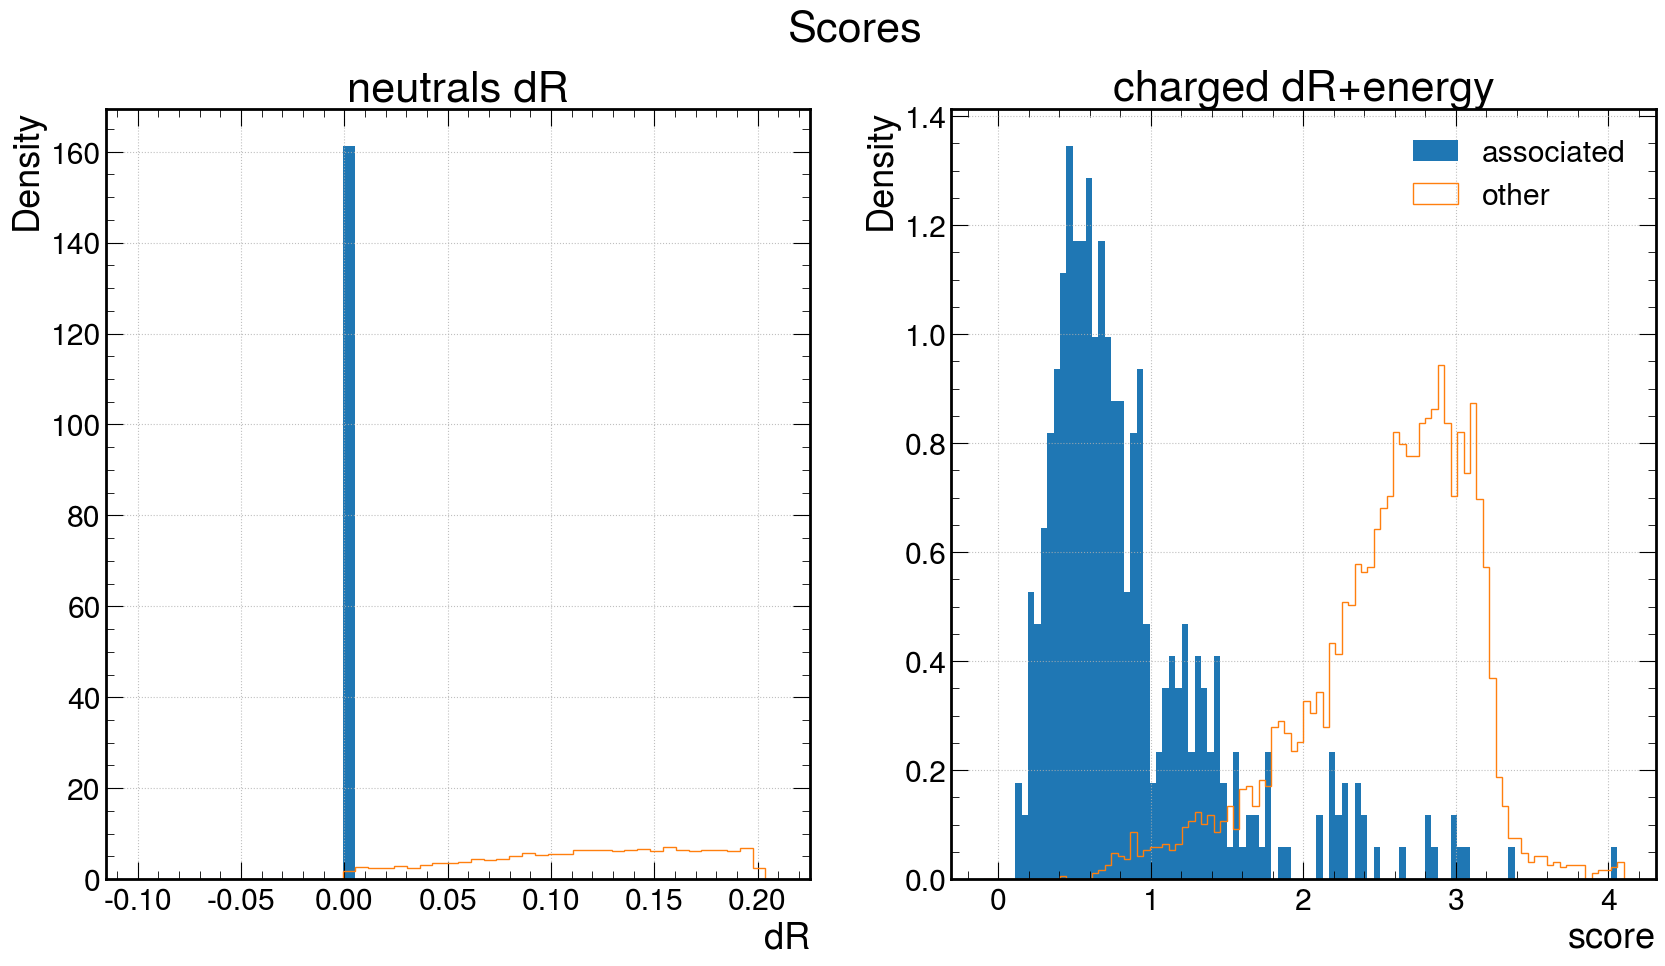

In [107]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Scores")
plt.subplot(1, 2, 1)
entriesAss, binEdgesAss, _ = plt.hist((allN_dR_ass), bins=50, density=True, label="associated", range=(-0.1,0.21)) #, range=(-4,4))
entries, binEdges, _ = plt.hist((allN_dR_other), bins=50, density=True, histtype="step", label="other", range=(-0.1,0.21)) #, range=(-4,4))
plt.xlabel(r"dR")
plt.ylabel("Density")
plt.title("neutrals dR")
plt.grid()

plt.subplot(1, 2, 2)
entries, binEdges, _ =plt.hist(allC_score_ass, bins=100, density=True, label="associated", range=(-0.1,4.1))
entries, binEdges, _ =plt.hist(allC_score_oth, bins=100, density=True, histtype="step", label="other", range=(-0.1,4.1))
plt.xlabel(r"score")
plt.ylabel("Density")
plt.title("charged dR+energy")
plt.legend()
plt.grid()

plt.show()

In [104]:
rEp_ass = arr(rEp_ass_all) 
rEp_oth = arr(rEp_other_all) 
dR_ass = arr(dR_ass_all) 
dR_oth = arr(dR_other_all) 
# pR_ass = arr(pull_dir_ass_all) 
# pR_oth = arr(pull_dir_other_all) 
dt_ass = arr(delta_t_ass_all) 
dt_oth = arr(delta_t_other_all) 
# pt_ass = arr(pull_time_ass_all) 
# pt_oth = arr(pull_time_other_all)

In [ ]:
sigma_rEp = np.std(rEp_ass)
sigma_pullR = np.std(pR_ass)

rEp_ass_norm = rEp_ass / sigma_rEp
pR_ass_norm  = pR_ass / sigma_pullR

rEp_oth_norm = rEp_oth / sigma_rEp
pR_oth_norm  = pR_oth / sigma_pullR

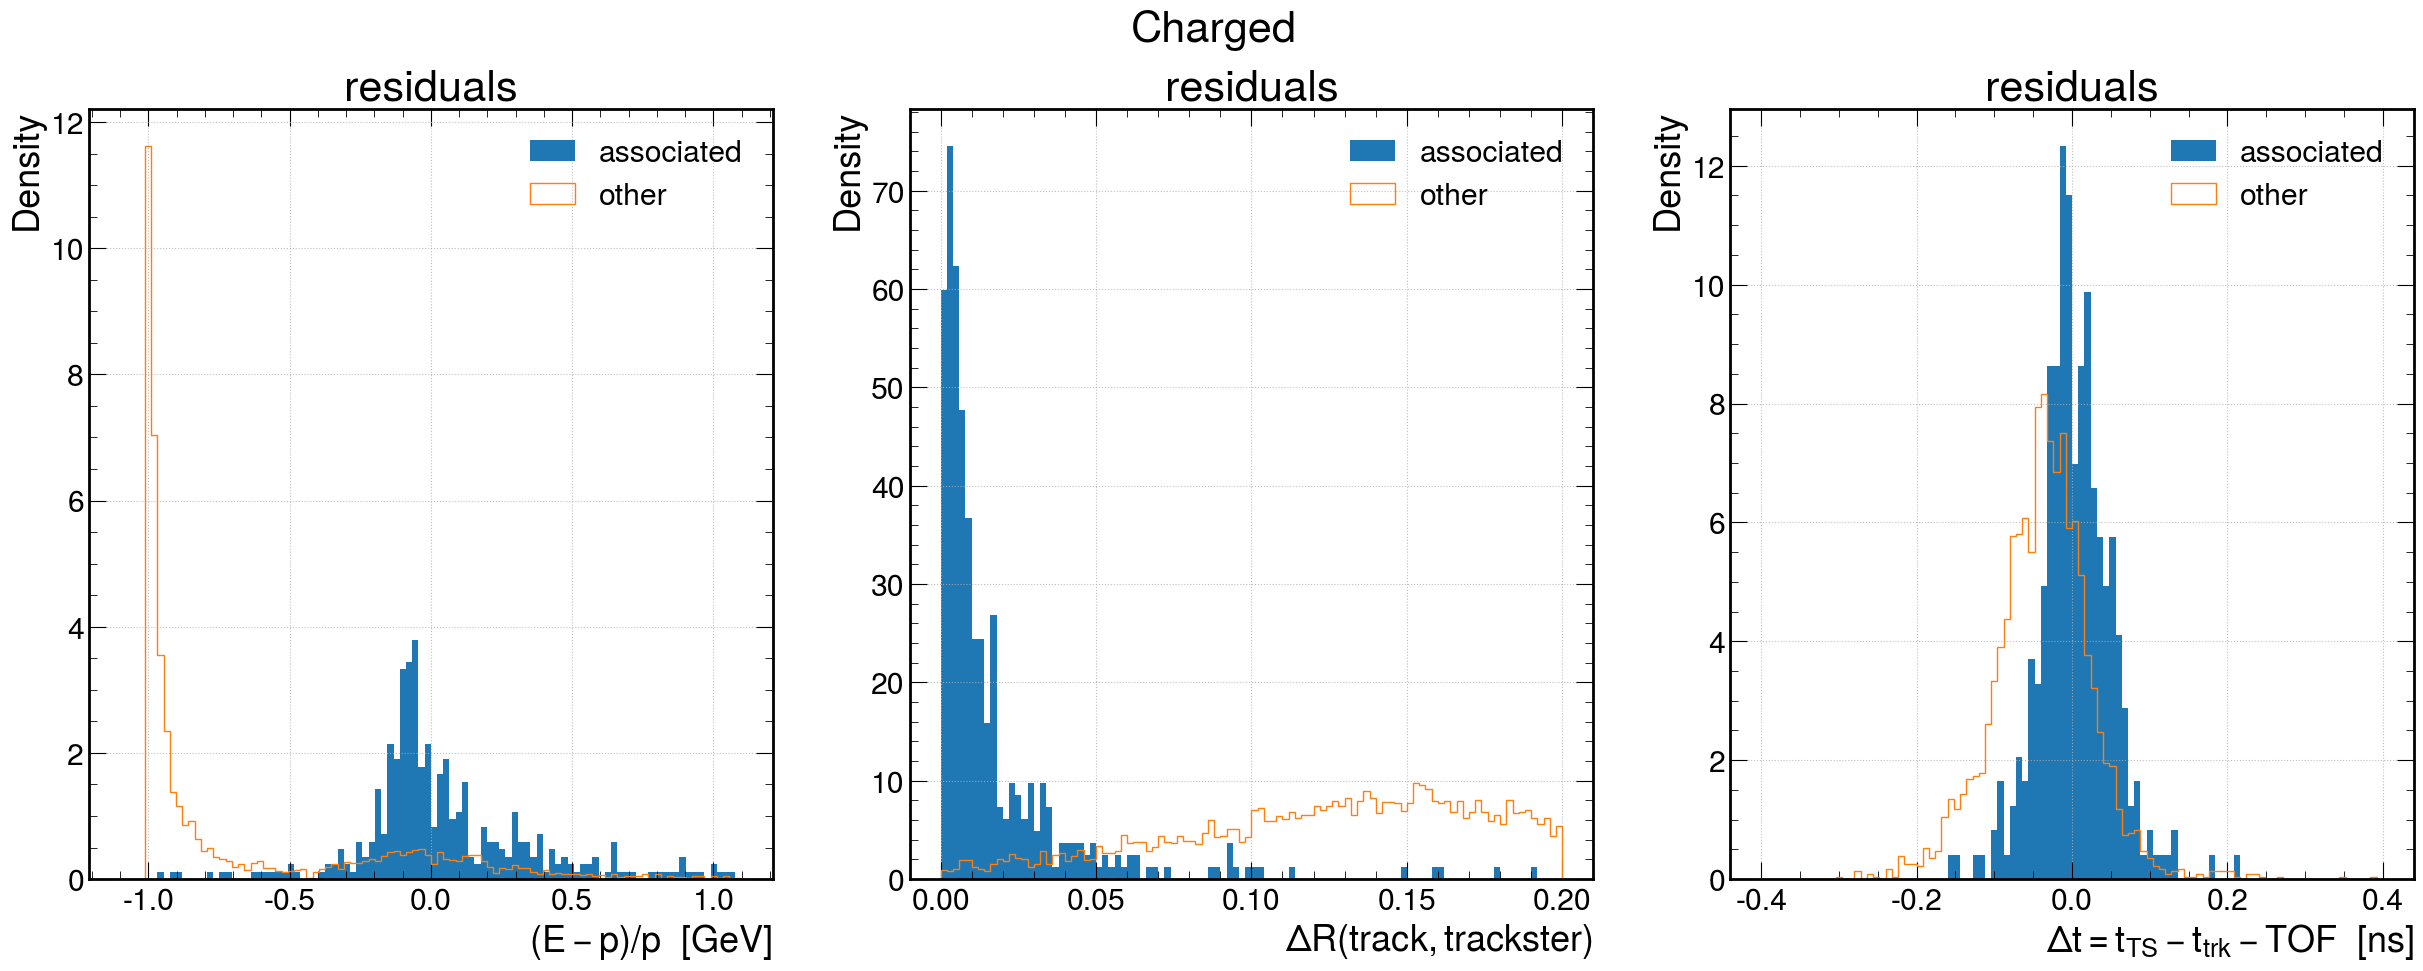

In [115]:
plt.style.use(hep.style.CMS)

# -------------------------
# 1) E/p residuals
# -------------------------
plt.figure(figsize=(30, 10))
plt.suptitle("Charged")
plt.subplot(1, 3, 1)
plt.hist(rEp_ass, bins=100, range=(-1.1,1.1), density=True, label="associated")
plt.hist(rEp_oth, bins=100, range=(-1.1,1.1), density=True, histtype="step", label="other")
plt.xlabel(r"$(E - p)/p$  [GeV]")
plt.ylabel("Density")
plt.title("residuals")
plt.legend()
plt.grid()

# plt.subplot(1, 2, 2)
# plt.hist(pEp_ass, bins=100, range=(-5,5), density=True, label="associated")
# plt.hist(pEp_oth, bins=100, range=(-5,5), density=True, histtype="step", label="other")
# plt.xlabel(r"$(E - f(p)\,p)/\sigma_{E/p}$")
# plt.ylabel("Density")
# plt.title("pulls")
# plt.legend()
# plt.grid()

# plt.subplot(1, 3, 3)
# plt.hist(rEp_ass_norm, bins=100, range=(-2,1), density=True, label="associated")
# plt.hist(rEp_oth_norm, bins=100, range=(-2,1), density=True, histtype="step", label="other")
# plt.xlabel(r"$E - f(p)\,p/\sigma_{E - f(p)\,p}$")
# plt.ylabel("Density")
# plt.title(f"residuals normalized ($\sigma$={sigma_rEp:.2f})")
# plt.legend()
# plt.grid()

# plt.show()

# -------------------------
# 2) Angular consistency
# -------------------------
# plt.figure(figsize=(20, 10))
# plt.suptitle("dR")
plt.subplot(1, 3, 2)
plt.hist(dR_ass, bins=100, range=(0,0.2), density=True, label="associated")
plt.hist(dR_oth, bins=100, range=(0,0.2), density=True, histtype="step", label="other")
plt.xlabel(r"$\Delta R(\mathrm{track}, \mathrm{trackster})$")
plt.ylabel("Density")
plt.legend()
plt.title("residuals")
plt.grid()

# plt.subplot(1, 2, 2)
# plt.hist(pR_ass, bins=100, range=(0,5), density=True, label="associated")
# plt.hist(pR_oth, bins=100, range=(0,5), density=True, histtype="step", label="other")
# plt.xlabel(r"$\Delta R / \sigma_{\mathrm{dir}}$")
# plt.ylabel("Density")
# plt.legend()
# plt.title("pulls")
# plt.grid()
# plt.show()

# # -------------------------
# # 3) Timing consistency
# # -------------------------
# plt.figure(figsize=(20, 10))
# plt.suptitle("dTime")
plt.subplot(1, 3, 3)
plt.hist(dt_ass[dt_ass!=0], bins=100, range=(-0.4,0.4), density=True, label="associated")
plt.hist(dt_oth[dt_oth!=0], bins=100, range=(-0.4,0.4), density=True, histtype="step", label="other")
plt.xlabel(r"$\Delta t = t_{\mathrm{TS}} - t_{\mathrm{trk}} - \mathrm{TOF}$  [ns]")
plt.ylabel("Density")
plt.legend()
plt.title("residuals")
plt.grid()

# plt.subplot(1, 2, 2)
# plt.hist(pt_ass, bins=100, range=(-5,5), density=True, label="associated")
# plt.hist(pt_oth, bins=100, range=(-5,5), density=True, histtype="step", label="other")
# plt.xlabel(r"$\Delta t / \sigma_t$")
# plt.ylabel("Density")
# plt.legend()
# plt.title("pulls")
# plt.grid()
# plt.show()

# # # -------------------------
# # # 4) Correlation checks (assoc only)
# # # -------------------------
# plt.figure(figsize=(20, 10))
# plt.suptitle("Correlation checks")
# plt.subplot(1, 2, 1)
# plt.hist2d(dR_ass, pEp_ass, bins = 30, range=[[0,0.15],[-5,5]])
# plt.xlabel(r"$\Delta R$")
# plt.ylabel(r"$E/p$ pull")
# plt.colorbar(label="Counts")
# plt.title("dR vs pull E/p")
# plt.grid()

# plt.subplot(1, 2, 2)
# plt.hist2d(dR_ass, pt_ass, bins = 30, range=[[0,0.15],[-5,5]])
# plt.xlabel(r"$\Delta R$")
# plt.ylabel(r"Time pull")
# plt.colorbar(label="Counts")
# plt.title("dR vs pull Time")
# plt.grid()
plt.show()

# # # -------------------------
# # # 5) Hard sanity prints
# # # -------------------------
# print("NaNs (E/p pull):", np.isnan(pEp_ass).sum())
# print("NaNs (time pull):", np.isnan(pt_ass).sum())
# print("|E/p pull| > 10:", np.sum(np.abs(pEp_ass) > 10))
# print("|time pull| > 10:", np.sum(np.abs(pt_ass) > 10))


In [ ]:
time_valid_ass = pt_ass != 0
time_valid_oth = pt_oth != 0
n_terms_ass = 2 + time_valid_ass
n_terms_oth = 2 + time_valid_oth

## tiles

In [297]:
class EtaPhiTiles:
    def __init__(self, eta_min, eta_max, n_eta=34, phi_min=-np.pi, phi_max=np.pi, n_phi=126):
        self.eta_min = eta_min
        self.eta_max = eta_max
        self.phi_min = phi_min
        self.phi_max = phi_max

        self.n_eta = n_eta
        self.n_phi = n_phi

        self.d_eta = (eta_max - eta_min) / n_eta
        self.d_phi = (phi_max - phi_min) / n_phi

        # 2D grid of lists
        self.tiles = [[[] for _ in range(n_phi)] for _ in range(n_eta)]

    def _eta_bin(self, eta):
        i = int((eta - self.eta_min) / self.d_eta)
        return max(0, min(self.n_eta - 1, i))

    def _phi_bin(self, phi):
        # wrap phi into [-pi, pi)
        while phi < -np.pi:
            phi += 2 * np.pi
        while phi >= np.pi:
            phi -= 2 * np.pi

        i = int((phi - self.phi_min) / self.d_phi)
        return max(0, min(self.n_phi - 1, i))
    
    def getEtaWidth(self):
        return self.d_eta
    
    def getPhiWidth(self):
        return self.d_phi
    
    def getNumEta(self):
        return self.n_eta
    
    def getNumPhi(self):
        return self.n_phi

    def fill(self, eta, phi, idx):
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)
        self.tiles[i_eta][i_phi].append(idx)

    def get_tile(self, eta, phi):
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)
        return self.tiles[i_eta][i_phi]
    
    def get_window(self, eta, phi, d_eta_bins=1, d_phi_bins=1):
        """Return all indices in neighboring bins"""
        i_eta = self._eta_bin(eta)
        i_phi = self._phi_bin(phi)

        out = []

        for ie in range(i_eta - d_eta_bins, i_eta + d_eta_bins + 1):
            if ie < 0 or ie >= self.n_eta:
                continue
            
            used = []
            for ip in range(i_phi - d_phi_bins, i_phi + d_phi_bins + 1):
                ip_wrapped = ip % self.n_phi  # φ wraps
                if ip_wrapped in used:
                    continue
                used.append(ip_wrapped)
                out.extend(self.tiles[ie][ip_wrapped])

        return out

In [19]:
def propagate_tracksters(barycenters, zVal):
    """
    barycenters: (N,3) array
    returns: eta, phi, endcap
    """
    baryc = barycenters
    norms = np.linalg.norm(baryc, axis=1)
    direct = baryc / norms[:, None]

    z = np.where(baryc[:, 2] > 0, zVal, -zVal)
    par = (z - baryc[:, 2]) / direct[:, 2]

    x = par * direct[:, 0] + baryc[:, 0]
    y = par * direct[:, 1] + baryc[:, 1]

    r = np.sqrt(x*x + y*y + z*z)
    eta = 0.5 * np.log((r + z) / (r - z))
    phi = np.arctan2(y, x)

    endcap = np.where(eta > 0, 1, 0)

    return eta, phi, endcap

# no diff in eta and phi if we use barycenter for propagation instead of PCA
# ev = 0
# tracksEv = tracks[ev]
# tsLinksEv = tracksterLinks[ev]
# #for idx in prange(len(tsLinksEv.raw_energy)):

# refEta = tsLinksEv.barycenter_eta
# refPhi = tsLinksEv.barycenter_phi       
# refX = tsLinksEv.barycenter_x       
# refY = tsLinksEv.barycenter_y       
# refZ = tsLinksEv.barycenter_z       
# barycenters= np.asarray([refX, refY, refZ]).T

# zVal = 322
# eta, phi, endcap = propagate_tracksters(barycenters, zVal)
# if ak.any(np.abs(eta-refEta)> 1e-5): print("diff eta")
# if ak.any(np.abs(phi-refPhi)> 1e-5): print("diff phi")

In [20]:
def fill_tiles(eta, phi, endcap, tracksterTiles):
    for idx in range(len(eta)):
        ec = endcap[idx]
        tracksterTiles[ec].fill(eta[idx], phi[idx], idx)

In [21]:
def find_candidates_for_tracks(trk_id, eta_trk, phi_trk, endcap_trk, tracksterTiles, d_eta_bins=1, d_phi_bins=1):
    all_candidates = {}

    for i in range(len(eta_trk)):
        ec = endcap_trk[i]
        cands = tracksterTiles[ec].get_window(
            eta_trk[i],
            phi_trk[i],
            d_eta_bins,
            d_phi_bins
        )
        all_candidates[trk_id[i]] = cands
        
    return all_candidates

# graph building

In [277]:
import networkx as nx

def ortools_to_networkx(mcf, nodes_id, tracks_eta, tracks_phi, tsEta, tsPhi, tsZ, include_zero_flow=False):
    G = nx.DiGraph()
    classify_node= {-1: "SRC", 0: "track", 1: "trackster", 2: "tracksterOUT", 3:"SNK"}
    n_tracks =  np.count_nonzero(nodes_id == 0) 
    n_ts =  np.count_nonzero(nodes_id == 1) 
#     print(f"{n_tracks=}, {n_ts=}")
    for u in range(len(nodes_id)):
        if nodes_id[u]== 0:
            trk_id = u - 1
            G.add_node(
                u,
                node_type=classify_node[nodes_id[u]],
                phi=tracks_phi[trk_id],
                eta=tracks_eta[trk_id]
            )
#             print('track node', u)
        elif nodes_id[u]==1:
            ts_id = u - 1 - n_tracks
            G.add_node(
                u,
                node_type=classify_node[nodes_id[u]],
                phi=tsPhi[ts_id],
                eta=tsEta[ts_id],
                z=tsZ[ts_id]
            )
#             print('ts node', u)

    for arc in range(mcf.num_arcs()):
        u = mcf.tail(arc)
        v = mcf.head(arc)
        
        if nodes_id[u]==-1 or nodes_id[v]==3: continue
        #if nodes_id[u]==3 or nodes_id[v]==-1: continue
        if nodes_id[u]==1 and nodes_id[v]==2: continue
        if u>n_tracks+n_ts:
            u = u -n_ts
        
        cap = mcf.capacity(arc)
        cost = mcf.unit_cost(arc)
        flow = mcf.flow(arc)

        if flow == 0 and not include_zero_flow:
            continue
        #print('edge between', u, v, mcf.tail(arc), "ids", nodes_id[mcf.tail(arc)], nodes_id[v])
        G.add_edge(
            u, v,
            capacity=cap,
            cost=cost,
            flow=flow
        )

    return G

In [22]:
@njit
def myFunc(x, y):
    y = np.abs(y)
    a = 2.29516386e-01
    b = -8.05371532e+02
    c = -6.45573586e-01
    d = 8.05370082e+02
    e = 1.00000033e+00
    f = -1.07458042e-04
    g = 4.79631755e-01
    h = 1.21330763e+00
    if x>200: x=200
    if y<1.7: y= 1.7
    val = a + b*x + c*y + d*x**e + f*x*y + g * y**h
    if val < 0.008: val =0.008
    return val

@njit
def compute_score(
    refPt, refEta, refPhi, refP,
    tsEta, tsPhi, tsEnergy, wEp=0.5
):
    rEp_norm = (tsEnergy - refP) / refP
    deltaPhi = refPhi - tsPhi
    deltaPhi = (deltaPhi + np.pi) % (2 * np.pi) - np.pi
    deta = refEta - tsEta
    dR2 = deta ** 2 + deltaPhi ** 2
    pullR2 = dR2 / myFunc(refPt, refEta)**2
    score = wEp * rEp_norm**2 + (1-wEp) * pullR2
    return score**0.5

In [23]:
@njit
def normTracksters(x, y):
    #x, y = energy ,eta
    y = np.abs(y)
    a = 1.49662496e+00 
    b = 4.04830636e+01 
    c = -1.19840947e+01 
    d = -4.04834456e+01
    e = 9.99984896e-01 
    f = -1.67329993e-03  
    g = 1.06828890e+01  
    h = 1.09862164e+00

    if x>200: x=200
    val = a + b*x + c*y + d*x**e + g * y**h  + f*x*y 
    return val #np.clip(val, 0.008, 1)
#     return (a + c*y**e )* x**b #+ e*y**2 + f*x*y

In [312]:
def fill_tiles_ec(eta, phi, tracksterTiles):
    for i in range(len(eta)):
        tracksterTiles.fill(eta[i], phi[i], i)
#         print("fill tile with ", eta[i], phi[i], idx[i])

def build_ts_edges(tsEta, tsPhi, tsZ, tsEnergy, tiles, dr_cut=0.05, shift=0.5, weight=4):
    edges = []
    dr_cut_2 = dr_cut**2
    
    for i in prange(len(tsEta)):
        eta_i = tsEta[i]
        phi_i = tsPhi[i]
        en_i = tsEnergy[i]
        # get neighboring candidate tracksters
        d_eta_bins = min(int(np.ceil(dr_cut / tiles.getEtaWidth())), tiles.getNumEta())
        d_phi_bins = min(int(np.ceil(dr_cut / tiles.getPhiWidth())), tiles.getNumPhi())
        neigh = tiles.get_window(eta_i, phi_i, d_eta_bins=d_eta_bins, d_phi_bins=d_phi_bins)
        #print(i , neigh, d_eta_bins, d_phi_bins, tsZ[i], tsZ[neigh], distWrap_numba(eta_i, phi_i, tsEta[neigh], tsPhi[neigh]))
        for j in neigh:
            # enforce outward direction
            if abs(tsZ[j]) <= abs(tsZ[i]):
                continue

            dr2 = distWrap2_numba(eta_i, phi_i, tsEta[j], tsPhi[j])
            
            if dr2 < dr_cut_2:
                en = max(en_i, tsEnergy[j])
                eta = eta_i if en_i>tsEnergy[j] else tsEta[j]
                edges.append((i, j, (dr2**0.5/normTracksters(en, eta)-shift)*weight))
                #print("appending ts edge ", ts_i, k, dr2**0.5)
    return edges

def build_trk_ts_edges(trkEta, trkPhi, trkPt, trkP, tsEta, tsPhi, tsEnergy, tiles, dr_cut=0.05, shift=1, weight=2): #FIXME bins in funzione del dR
    edges = []
    dr_cut_2 = dr_cut**2
    
    for i in range(len(trkEta)):
        eta_i = trkEta[i]
        phi_i = trkPhi[i]
        pt_i = trkPt[i]
        p_i = trkP[i]
        # get neighboring candidate tracksters
        d_eta_bins = min(int(np.ceil(dr_cut / tiles.getEtaWidth())), tiles.getNumEta())
        d_phi_bins = min(int(np.ceil(dr_cut / tiles.getPhiWidth())), tiles.getNumPhi())
        neigh = tiles.get_window(eta_i, phi_i, d_eta_bins=d_eta_bins, d_phi_bins=d_phi_bins)

        for j in neigh:
            dr2 = distWrap2(eta_i, phi_i, tsEta[j], tsPhi[j])

            if dr2 < dr_cut_2:
                score = compute_score(pt_i, eta_i, phi_i, p_i, tsEta[j], tsPhi[j], tsEnergy[j])
                edges.append((i, j, (score-shift)*weight))
#                 print("appending trk edge ", i, j, score)
    return edges

In [319]:
def compute_sim_score_mcf(arc_cost, true_links, tracks_id, tsIdMap, tsZ, SRC, SNK, TRACK_OFFSET, TS_IN_OFFSET):

    # Map track and TS to internal node indices
    track_map = {tid: i + TRACK_OFFSET for i, tid in enumerate(tracks_id)}
    ts_map = {ts: i + TS_IN_OFFSET for i, ts in enumerate(tsIdMap)}
    tsZ = np.abs(tsZ)
    total_cost = 0

    for tl in true_links:
        trk = tl["track_id"]
        tsList = tl["reco_ts"]
        ts_indices = np.array([ts_map[ts] for ts in tsList])
        n_TS = len(ts_indices)
        mcf = min_cost_flow.SimpleMinCostFlow()
        
        if trk is None or trk[0] not in track_map:
            for i, ts in enumerate(ts_indices):
                mcf.add_arc_with_capacity_and_unit_cost(SRC, ts, 1, arc_cost[(SRC, ts)])  
                mcf.add_arc_with_capacity_and_unit_cost(ts, SNK, 1, arc_cost[(ts, SNK)])
                for other in ts_indices[ts_indices!=ts]:
                    if tsZ[other - TS_IN_OFFSET] > tsZ[ts - TS_IN_OFFSET]:
                        mcf.add_arc_with_capacity_and_unit_cost(ts, other, 1, arc_cost[(ts, other)])
        else: 
            trk_idx = track_map[trk[0]] 
            mcf.add_arc_with_capacity_and_unit_cost(SRC, trk_idx, n_TS, arc_cost[(SRC, trk_idx)])

            for ts in ts_indices:
                mcf.add_arc_with_capacity_and_unit_cost(trk_idx, ts, 1, arc_cost[(trk_idx, ts)])  
                mcf.add_arc_with_capacity_and_unit_cost(ts, SNK, 1, arc_cost[(ts, SNK)])
                for other in ts_indices[ts_indices!=ts]:
                    if tsZ[other - TS_IN_OFFSET] > tsZ[ts - TS_IN_OFFSET]:
                        mcf.add_arc_with_capacity_and_unit_cost(ts, other, 1, arc_cost[(ts, other)])

        mcf.set_node_supply(SRC, n_TS)
        mcf.set_node_supply(SNK, -n_TS)
        status = mcf.solve()
        if status != mcf.OPTIMAL:
            raise RuntimeError("Min-cost flow did not find an optimal solution")
        for arc in range(mcf.num_arcs()):
            flow = mcf.flow(arc)
            if flow <= 0:
                continue
#             u = mcf.tail(arc)
#             v = mcf.head(arc)

#             print(
#                 f"{u:4d}->{v:4d}   "
#                 f"{mcf.unit_cost(arc) * flow:7d}"
#             )
            total_cost += mcf.unit_cost(arc) * flow

#         G = nx.DiGraph()
        
#         if trk is None:
#             # Neutral TS: source -> TS -> SNK
#             nodes = [SRC] + list(ts_indices) + [SNK]
#             G.add_nodes_from(nodes)
#             for ts in ts_indices:
#                 G.add_edge(SRC, ts, capacity=len(ts_indices), weight=arc_cost[(SRC, ts)])
#                 G.add_edge(ts, SNK, capacity=len(ts_indices), weight=arc_cost[(ts, SNK)])
#             # TS -> TS forward edges
#             for i, u in enumerate(ts_indices):
#                 for v in ts_indices[i+1:]:
#                     G.add_edge(u, v, capacity=len(ts_indices), weight=arc_cost[(u, v)])
#         else:
#             # Charged track
#             trk_idx = track_map[trk[0]]  # assume one track
#             nodes = [SRC, trk_idx] + list(ts_indices) + [SNK]
#             G.add_nodes_from(nodes)
#             G.add_edge(SRC, trk_idx, capacity=len(ts_indices), weight=arc_cost[(SRC, trk_idx)])
#             # Track -> TS edges
#             for ts in ts_indices:
#                 G.add_edge(trk_idx, ts, capacity=len(ts_indices), weight=arc_cost[(trk_idx, ts)])
#                 G.add_edge(ts, SNK, capacity=len(ts_indices), weight=arc_cost[(ts, SNK)])
#             # TS -> TS forward edges
#             for i, u in enumerate(ts_indices):
#                 for v in ts_indices[i+1:]:
#                     G.add_edge(u, v, capacity=len(ts_indices), weight=arc_cost[(u, v)])
        
#         pos = nx.bfs_layout(G, SRC)
#         nx.draw(G, pos, with_labels=True, node_size=1500)
#         edge_labels = nx.get_edge_attributes(G, 'weight')
#         nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
#         plt.show()
        
    return total_cost
        


In [320]:
from collections import defaultdict
from ortools.graph.python import min_cost_flow

# does not allow tracksters sharing between candidates
def build_and_solve_flow_event_singleTs(tracksEv, tsLinksEv, endcap, 
                                        dr_cut=0.02, neutral_penalty=1.0, ts_ts_score_shift=0.5, track_ts_score_shift=1,
                                        ts_ts_score_weight=1, track_ts_score_weight=1, n_eta = 30, debug=False):
    # Filter tracks and tracksters
    if endcap == 0:
        mask3 = tracksEv.track_hgcal_eta < 0
        tsMask = tsLinksEv.barycenter_eta < 0
        tracksterTiles_ec = EtaPhiTiles(eta_min=-3.0, eta_max=-1.5, n_eta=n_eta)
    else:
        mask3 = tracksEv.track_hgcal_eta > 0
        tsMask = tsLinksEv.barycenter_eta > 0
        tracksterTiles_ec = EtaPhiTiles(eta_min= 1.5, eta_max= 3.0, n_eta=n_eta)
        
    mask1 = np.logical_and(tracksEv.track_hgcal_pt >= 1.0, tracksEv.track_p >= 2.0)
    mask2 = np.logical_and(np.abs(tracksEv.track_hgcal_eta) >= 1.5,
                           np.abs(tracksEv.track_hgcal_eta) <= 3.0)
    mask = mask1 & mask2 & mask3

    tracks_id = tracksEv.track_id[mask]
    tracks_eta = tracksEv.track_hgcal_eta[mask]
    tracks_phi = tracksEv.track_hgcal_phi[mask]
    tracks_pt = tracksEv.track_hgcal_pt[mask]
    tracks_p = tracksEv.track_p[mask]

    n_tracks = len(tracks_id)
    tsIdMap = np.arange(len(tsLinksEv.barycenter_eta))[tsMask]
    tsEta = tsLinksEv.barycenter_eta[tsMask]
    tsPhi = tsLinksEv.barycenter_phi[tsMask]
    tsZ = tsLinksEv.barycenter_z[tsMask]
    tsEnergy = tsLinksEv.raw_energy[tsMask]
    n_TS = len(tsEnergy)
    
    # tiles filling
    fill_tiles_ec(tsEta, tsPhi, tracksterTiles_ec)

    # Track→TS edges
    track_ts_edges = build_trk_ts_edges(tracks_eta, tracks_phi, tracks_pt, tracks_p, tsEta, tsPhi, tsEnergy, tracksterTiles_ec, dr_cut=dr_cut, shift=track_ts_score_shift, weight=track_ts_score_weight)

    # TS→TS edges
    ts_ts_edges = build_ts_edges(tsEta, tsPhi, tsZ, tsEnergy, tracksterTiles_ec, dr_cut=dr_cut, shift=ts_ts_score_shift, weight=ts_ts_score_weight)

    mcf = min_cost_flow.SimpleMinCostFlow()
    SRC = 0
    TRACK_OFFSET = 1
    TS_IN_OFFSET = TRACK_OFFSET + n_tracks
    TS_OUT_OFFSET = TS_IN_OFFSET + n_TS
    SNK = TS_OUT_OFFSET + n_TS
    N_total = SNK + 1

    node_id = np.zeros(N_total)
    node_id[SRC] = -1
    node_id[TRACK_OFFSET:TS_IN_OFFSET] = 0
    node_id[TS_IN_OFFSET:TS_OUT_OFFSET] = 1
    node_id[TS_OUT_OFFSET:SNK] = 2
    node_id[SNK] = 3
    
    # 3a. Source → Track
    for trk_idx in range(n_tracks):
        mcf.add_arc_with_capacity_and_unit_cost(SRC, TRACK_OFFSET + trk_idx, n_TS, -100)
    
    # 3a-bis. Source → TS (neutral start)
    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(SRC, TS_IN_OFFSET + ts_idx, 1, 0)

    # 3b. Track → TS
    for trk_idx, ts_idx, score in track_ts_edges:
        mcf.add_arc_with_capacity_and_unit_cost(TRACK_OFFSET + trk_idx, TS_IN_OFFSET + ts_idx, 1, int(score*1000))  # OR-Tools requires integer costs

    # 3c. TSin → TSout (same trackster for exclusivity)
    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(TS_IN_OFFSET + ts_idx, TS_OUT_OFFSET + ts_idx, 1, 0) # capacity = 1 → exclusivity 
        
    # 3c-bis. TS → TS
    for i, j, score in ts_ts_edges:
        mcf.add_arc_with_capacity_and_unit_cost(TS_OUT_OFFSET + i, TS_IN_OFFSET + j, 1, int(score*1000))

    # 3d. TS → Sink (neutral)
    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(TS_OUT_OFFSET + ts_idx, SNK, 1, int(neutral_penalty*1000))

    # 3e. Track → Sink (track-only)
    for trk_idx in range(n_tracks):
        mcf.add_arc_with_capacity_and_unit_cost(TRACK_OFFSET + trk_idx, SNK, 1, int(neutral_penalty*1000))

    # 3f. Supplies
    mcf.set_node_supply(SRC, n_TS)
    mcf.set_node_supply(SNK, -n_TS)
    # Tracks and TS nodes = 0 (default)

    # --------------------
    # 4. Solve min-cost flow
    # --------------------
    def arc_type(u, v):
        if u == SRC:
            return "SRC→*"
        if TRACK_OFFSET <= u < TS_IN_OFFSET and TS_IN_OFFSET <= v < TS_OUT_OFFSET:
            return "TRK→TS"
        if TS_IN_OFFSET <= u < TS_OUT_OFFSET and TS_OUT_OFFSET <= v < SNK:
            return "INTERNAL TS"
        if TS_OUT_OFFSET <= u < SNK and TS_IN_OFFSET <= v < TS_OUT_OFFSET:
            return "TS→TS"
        if v == SNK:
            return "*→SNK"
        return "OTHER"

    status = mcf.solve()
    if status != mcf.OPTIMAL:
        raise RuntimeError("Min-cost flow did not find an optimal solution")
        
    total_cost = 0
    for arc in range(mcf.num_arcs()):
        flow = mcf.flow(arc)
        if flow <= 0:
            continue
        cap = mcf.capacity(arc)
        unit_cost = mcf.unit_cost(arc)
        cost = flow * unit_cost

        u = mcf.tail(arc)
        v = mcf.head(arc)
        
        total_cost += cost

    #print("Total cost:", total_cost)
    
    if debug:
        gNx = ortools_to_networkx(mcf, node_id, tracks_eta, tracks_phi, tsEta, tsPhi, tsZ)

    # --------------------
    # 5. Decode flow into candidates
    # --------------------
    used_out = defaultdict(list)
    for arc in range(mcf.num_arcs()):
        if mcf.flow(arc) > 0:
            u = mcf.tail(arc)
            v = mcf.head(arc)
            used_out[u].append(v)
    
    charged_candidates = []
    for trk_node in used_out[SRC]:
        if not (TRACK_OFFSET <= trk_node < TS_IN_OFFSET):
            continue

        trk_idx = trk_node - TRACK_OFFSET
        ts_set = []
        # follow all outgoing branches from the track
        for v in used_out.get(trk_node, []):
            cur = v
            while cur != SNK:
                # TS_in
                if TS_IN_OFFSET <= cur < TS_OUT_OFFSET:
                    ts_set.append(cur - TS_IN_OFFSET)

                nexts = used_out.get(cur, [])
                if len(nexts) == 0 or len(nexts) > 1:
                    raise RuntimeError("Branching below TS_in should not happen and should be linked with SNK "+str(nexts))
                cur = nexts[0]

        charged_candidates.append({
            "track": int(tracks_id[trk_idx]), # [trk_idx, int(tracks_id[trk_idx])],
            "tracksters": [int(tsIdMap[ts_idx]) for ts_idx in ts_set] #(ts_idx, 
        })

#     used_ts = [ts for c in charged_candidates for ts in c["tracksters"]]
    
    neutral_candidates = []
    for start in used_out[SRC]:
        if not (TS_IN_OFFSET <= start < TS_OUT_OFFSET):
            continue

        ts_idx = start - TS_IN_OFFSET

        cur = start
        ts_chain = []
        while cur != SNK:
            if TS_IN_OFFSET <= cur < TS_OUT_OFFSET:
                ts_chain.append(cur - TS_IN_OFFSET)

            nexts = used_out.get(cur, [])
            if len(nexts) == 0:
                print("why not SNK?")
                break

            cur = nexts[0]

        neutral_candidates.append({
            "track": None,
            "tracksters": [int(tsIdMap[ts_idx]) for ts_idx in ts_chain] 
        })

    candidates = charged_candidates + neutral_candidates

    if debug:
        return candidates, gNx, total_cost
    else:
        return candidates, 0, total_cost

In [321]:
# sim ost
def build_flow_event_singleTs(tracksEv, tsLinksEv, true_links, endcap, 
                              dr_cut=0.02, neutral_penalty=1.0, ts_ts_score_shift=0.5, track_ts_score_shift=1,
                              ts_ts_score_weight=1, track_ts_score_weight=1, n_eta = 30):
    # Filter tracks and tracksters
    if endcap == 0:
        mask3 = tracksEv.track_hgcal_eta < 0
        tsMask = tsLinksEv.barycenter_eta < 0
        tracksterTiles_ec = EtaPhiTiles(eta_min=-3.0, eta_max=-1.5, n_eta=n_eta)
    else:
        mask3 = tracksEv.track_hgcal_eta > 0
        tsMask = tsLinksEv.barycenter_eta > 0
        tracksterTiles_ec = EtaPhiTiles(eta_min= 1.5, eta_max= 3.0, n_eta=n_eta)
        
    mask1 = np.logical_and(tracksEv.track_hgcal_pt >= 1.0, tracksEv.track_p >= 2.0)
    mask2 = np.logical_and(np.abs(tracksEv.track_hgcal_eta) >= 1.5,
                           np.abs(tracksEv.track_hgcal_eta) <= 3.0)
    mask = mask1 & mask2 & mask3

    tracks_id = tracksEv.track_id[mask]
    tracks_eta = tracksEv.track_hgcal_eta[mask]
    tracks_phi = tracksEv.track_hgcal_phi[mask]
    tracks_pt = tracksEv.track_hgcal_pt[mask]
    tracks_p = tracksEv.track_p[mask]

    n_tracks = len(tracks_id)
    tsIdMap = np.arange(len(tsLinksEv.barycenter_eta))[tsMask]
    tsEta = tsLinksEv.barycenter_eta[tsMask]
    tsPhi = tsLinksEv.barycenter_phi[tsMask]
    tsZ = tsLinksEv.barycenter_z[tsMask]
    tsEnergy = tsLinksEv.raw_energy[tsMask]
    n_TS = len(tsEnergy)
    
    # tiles filling
    fill_tiles_ec(tsEta, tsPhi, tracksterTiles_ec)

    track_ts_edges = build_trk_ts_edges(tracks_eta, tracks_phi, tracks_pt, tracks_p, tsEta, tsPhi, tsEnergy, tracksterTiles_ec, dr_cut=dr_cut, shift=track_ts_score_shift, weight=track_ts_score_weight)
    ts_ts_edges = build_ts_edges(tsEta, tsPhi, tsZ, tsEnergy, tracksterTiles_ec, dr_cut=dr_cut, shift=ts_ts_score_shift, weight=ts_ts_score_weight)

    mcf = min_cost_flow.SimpleMinCostFlow()
    SRC = 0
    TRACK_OFFSET = 1
    TS_IN_OFFSET = TRACK_OFFSET + n_tracks
    TS_OUT_OFFSET = TS_IN_OFFSET + n_TS
    SNK = TS_OUT_OFFSET + n_TS
    N_total = SNK + 1
    
    node_id = np.zeros(N_total)
    node_id[SRC] = -1
    node_id[TRACK_OFFSET:TS_IN_OFFSET] = 0
    node_id[TS_IN_OFFSET:TS_OUT_OFFSET] = 1
    node_id[TS_OUT_OFFSET:SNK] = 2
    node_id[SNK] = 3
    
    for trk_idx in range(n_tracks):
        mcf.add_arc_with_capacity_and_unit_cost(SRC, TRACK_OFFSET + trk_idx, n_TS, -100)
    
    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(SRC, TS_IN_OFFSET + ts_idx, 1, 0)

    for trk_idx, ts_idx, score in track_ts_edges:
        mcf.add_arc_with_capacity_and_unit_cost(TRACK_OFFSET + trk_idx, TS_IN_OFFSET + ts_idx, 1, int(score*1000))  # OR-Tools requires integer costs

    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(TS_IN_OFFSET + ts_idx, TS_OUT_OFFSET + ts_idx, 1, 0) # capacity = 1 → exclusivity 
        
    for i, j, score in ts_ts_edges:
        mcf.add_arc_with_capacity_and_unit_cost(TS_OUT_OFFSET + i, TS_IN_OFFSET + j, 1, int(score*1000))

    for ts_idx in range(n_TS):
        mcf.add_arc_with_capacity_and_unit_cost(TS_OUT_OFFSET + ts_idx, SNK, 1, int(neutral_penalty*1000))

    for trk_idx in range(n_tracks):
        mcf.add_arc_with_capacity_and_unit_cost(TRACK_OFFSET + trk_idx, SNK, 1, int(neutral_penalty*1000))

    mcf.set_node_supply(SRC, n_TS)
    mcf.set_node_supply(SNK, -n_TS)

    status = mcf.solve()
    if status != mcf.OPTIMAL:
        raise RuntimeError("Min-cost flow did not find an optimal solution")
        
    def arc_type(u, v):
        if u == SRC:
            return "SRC→*"
        if TRACK_OFFSET <= u < TS_IN_OFFSET and TS_IN_OFFSET <= v < TS_OUT_OFFSET:
            return "TRK→TS"
        if TS_IN_OFFSET <= u < TS_OUT_OFFSET and TS_OUT_OFFSET <= v < SNK:
            return "INTERNAL TS"
        if TS_OUT_OFFSET <= u < SNK and TS_IN_OFFSET <= v < TS_OUT_OFFSET:
            return "TS→TS"
        if v == SNK:
            return "*→SNK"
        return "OTHER"
    
    arc_cost = {}
#     print(" ArcType   u -> v   Flow / Cap   Unit Cost   Cost")
    for arc in range(mcf.num_arcs()):
        flow = mcf.flow(arc)
        cap = mcf.capacity(arc)
        unit_cost = mcf.unit_cost(arc)
        cost = unit_cost * flow

        u = mcf.tail(arc)
        v = mcf.head(arc)
        typeArc = arc_type(u,v)
        if typeArc == "TS→TS":
            u = u - n_TS
        if typeArc == "*→SNK" and u >= TS_OUT_OFFSET:
            u = u - n_TS
#         print(
#             f"{typeArc:8s} "
#             f"{u:4d}->{v:4d}   "
#             f"{flow:3d}/{cap:3d}   "
#             f"{unit_cost:7d}   "
#             f"{cost:7d}"
#         )   
        arc_cost[(u, v)] = unit_cost

    if np.any(mask) or np.any(tsMask):
        total_sim_cost = compute_sim_score_mcf(arc_cost, true_links, tracks_id, tsIdMap, tsZ, SRC, SNK, TRACK_OFFSET, TS_IN_OFFSET)
        #print("Total sim cost:", total_sim_cost)
    return total_sim_cost

In [322]:
tot_events = len(tracks)
all_candidates = []
all_graphs = []
diff=[]
for ev in tqdm(prange(tot_events)):
    #ev=305
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]
    true_linksEv = true_links[ev]

    for endcap in [1]:
        dRmax       =  0.035713
        ts_shift    =  0.264567
        trk_shift   =  1.194681
        ts_weight   = 14.831249
        trk_weight  = 14.151130
        neutral     = 10.215395
#         dRmax        =  0.057350
#         ts_shift     =  3.475756
#         trk_shift    =  3.222976
#         ts_weight    = 48.438624
#         trk_weight   = 63.164040
#         neutral      = 45.278175
#         candidates_ec, graph_ec, reco_cost = build_and_solve_flow_event_singleTs(tracksEv, tsLinksEv, endcap=endcap, dr_cut=dRmax, ts_ts_score_shift=ts_shift, track_ts_score_shift=trk_shift, ts_ts_score_weight=ts_weight, track_ts_score_weight=trk_weight, neutral_penalty=neutral, debug=False)
#         all_candidates.append(candidates_ec)
#         all_graphs.append(graph_ec)
        
        dRmax       =  100
        sim_cost = build_flow_event_singleTs(tracksEv, tsLinksEv, true_linksEv, endcap=endcap, dr_cut=dRmax, ts_ts_score_shift=ts_shift, track_ts_score_shift=trk_shift, ts_ts_score_weight=ts_weight, track_ts_score_weight=trk_weight, neutral_penalty=neutral)
        diff.append(reco_cost-sim_cost)

100%|██████████| 1000/1000 [07:45<00:00,  2.15it/s]


(array([  2.,   0.,   0.,   0.,   1.,   0.,   1.,   1.,   5.,   2.,   1.,
          4.,   3.,   3.,   5.,   6.,   5.,  12.,  10.,  22.,  21.,  46.,
         40.,  69., 101., 116., 165., 161., 146.,  52.]),
 array([-549551.        , -523290.96666667, -497030.93333333,
        -470770.9       , -444510.86666667, -418250.83333333,
        -391990.8       , -365730.76666667, -339470.73333333,
        -313210.7       , -286950.66666667, -260690.63333333,
        -234430.6       , -208170.56666667, -181910.53333333,
        -155650.5       , -129390.46666667, -103130.43333333,
         -76870.4       ,  -50610.36666667,  -24350.33333333,
           1909.7       ,   28169.73333333,   54429.76666667,
          80689.8       ,  106949.83333333,  133209.86666667,
         159469.9       ,  185729.93333333,  211989.96666667,
         238250.        ]),
 <BarContainer object of 30 artists>)

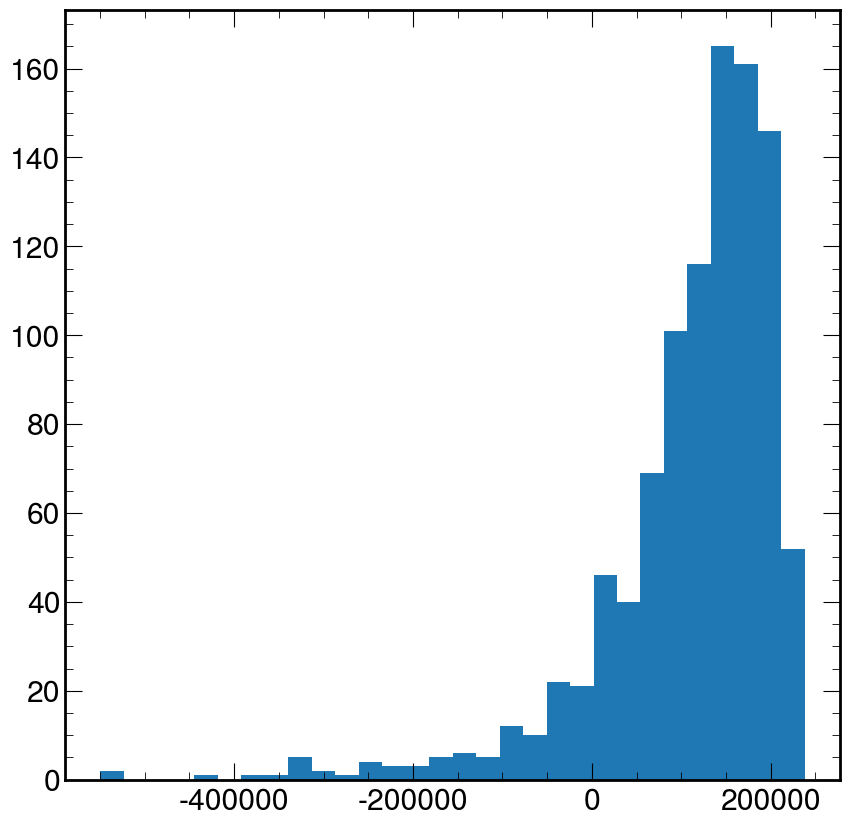

In [324]:
plt.hist(diff, bins=30)

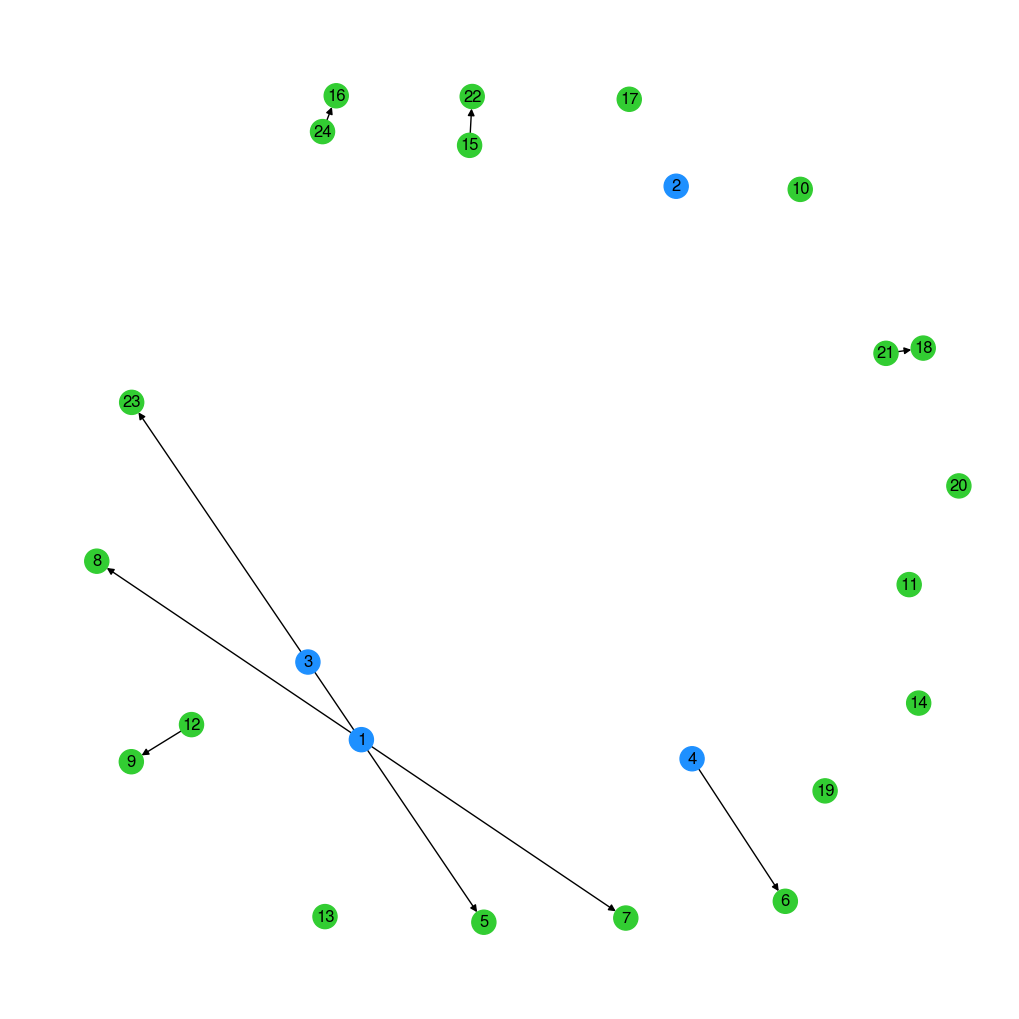

In [365]:
g0 = all_graphs[-1] #ortools_to_networkx(mcf_ec, nodes_id)
color_map = {
    "SRC": "red",
    "track": "dodgerblue",
    "trackster": "limegreen",
    "SNK": "gray"
}

node_colors = [
    color_map[g0.nodes[n]["node_type"]] for n in g0.nodes()
]

nx.draw(g0, node_color=node_colors, with_labels=True)

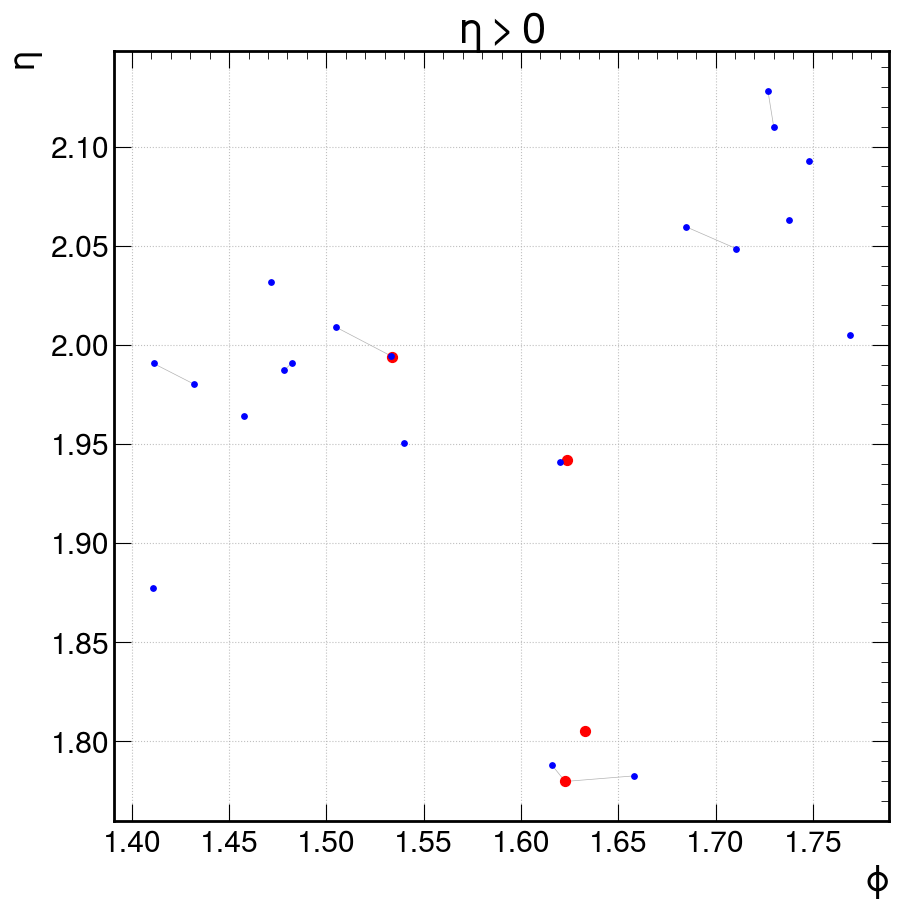

In [366]:
# Build positions
pos = {
    n: (d["phi"], d["eta"])
    for n, d in g0.nodes(data=True)
    if "phi" in d and "eta" in d
}

# Split nodes by type and eta sign
trk_pos = [n for n, d in g0.nodes(data=True) if d["node_type"]=="track"]
ts_pos  = [n for n, d in g0.nodes(data=True) if d["node_type"]=="trackster"]


etas = [v[1] for v in pos.values()]
phis = [v[0] for v in pos.values()]
phi_min, phi_max = min(phis), max(phis)
eta_min, eta_max = min(etas), max(etas)

plt.figure()
ax1 = plt.subplot(1,1,1)
nx.draw_networkx_nodes(g0, pos, nodelist=trk_pos, node_color="red", node_size=50, ax=ax1, label="tracks")
nx.draw_networkx_nodes(g0, pos, nodelist=ts_pos, node_color="blue", node_size=15, ax=ax1, label="tracksters")
nx.draw_networkx_edges(g0, pos, edgelist=[e for e in g0.edges if e[0] in trk_pos or e[1] in ts_pos],
                       edge_color="gray", alpha=0.6, ax=ax1, width=0.5, arrows=False)

ax1.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax1.set_xlim(phi_min- 0.02, phi_max+0.02)
ax1.set_ylim(eta_min- 0.02, eta_max+0.02)
# ax1.set_xticks(np.linspace(phi_min, phi_max, 4))
# #ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
# ax1.set_yticks(np.linspace(eta_min, eta_max, 4))
ax1.set_xlabel(r"$\phi$")
ax1.set_ylabel(r"$\eta$")
ax1.set_title(r"$\eta > 0$")
# ax1.legend()
ax1.grid(True)
plt.show()

## baseline validation

In [30]:
@njit
def find_in_array_with_none(array, match):
    for i, el in enumerate(array):
        if len(el) == 0: continue
        if el[0] == match:
            return i
    return -1

In [31]:
ene_baseline = []
eta_baseline = []
match_baseline =[]
for ev in tqdm(range(len(simtrackstersSC))):
    cands = candidates[ev]
    candTs = candTracksters[ev]
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersSC[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0 or stsSCEv.trackIdx[i][0]==-1:
            continue
        track_to_cp[stsSCEv.trackIdx[i][0]] = stsSCEv.CPidx[i]
    
    for idx in range(len(stsSCEv.trackIdx)):
        track = stsSCEv.trackIdx[idx]
        pid = np.abs(stsSCEv.pdgID[idx])
        if pid != 11 and pid != 211: continue
        if not len(track) or -1 in track: continue
        track= track[0]
        
        recoAssScore = associations[ev].ticlCandidate_simToReco_SC_score[idx]
        recoAssEne = associations[ev].ticlCandidate_simToReco_SC_sharedE[idx]
        recoAssIdx = associations[ev].ticlCandidate_simToReco_SC[idx]
        good = np.logical_and(recoAssScore<0.999 , recoAssEne / candTs.raw_energy[recoAssIdx] > 0.5)
        if not np.any(good): continue
        
        recoAssScore = recoAssScore[good]
        recoAssIdx = recoAssIdx[good]
        recoAssEne = recoAssEne[good]
        
#         print(track)
        trk_pos = find_track_id(tracksEv.track_id, track) 
        if trk_pos == -1:
            continue

        # Track kinematics
        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p  = tracksEv.track_p[trk_pos]
        if pt < 1 or p < 2: continue

        eta_baseline.append(stsSCEv.barycenter_eta[idx])
        ene_baseline.append(stsSCEv.regressed_energy[idx])

        match =False
        cp_idx = track_to_cp.get(track)
#         print(recoAssIdx)
        for recoAssId in recoAssIdx:
            candId = find_in_array_with_none(cands.tracksters_in_candidate, recoAssId)
            if candId==-1: continue
            track_in_cand = cands.track_in_candidate[candId]   
#             print(track_in_cand)
            if track == track_in_cand:
                match_baseline.append(1)
                match=True
                break
            #print(track, tracks_in_cand)
            if track_to_cp.get(track_in_cand) == cp_idx:
                match_baseline.append(1)
                match = True
                break
#         print(match, "\n---")
        if not match:
            match_baseline.append(0)

100%|██████████| 1000/1000 [00:37<00:00, 26.44it/s]


In [49]:
eta_bins = np.linspace(1.6, 2.9 ,10)
pt_bins = np.logspace(0.9 , 2.7 ,10) #this is energy not pt

In [33]:
match_baseline = arr(match_baseline)
eta_baseline = np.abs(arr(eta_baseline))
pt_baseline = arr(ene_baseline)

effBaseline_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_baseline >= eta_bins[i]) & (eta_baseline < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        effBaseline_eta.append(0)
    else:
        effBaseline_eta.append(np.mean(match_baseline[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
effBaseline_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (pt_baseline >= pt_bins[i]) & (pt_baseline < pt_bins[i+1])

    if np.sum(mask) == 0:
        effBaseline_pt.append(0)
    else:
        effBaseline_pt.append(np.mean(match_baseline[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

## validazione new

In [50]:
eff_flags = []
cp_consistent_mistake = []
eta_vals = []
ene_vals = []
wrong = []

for ev in tqdm(range(len(simtrackstersSC))):

    stsSCEv   = simtrackstersSC[ev]
    tracksEv  = tracks[ev]

    # Build reco link lookup
    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0 or stsSCEv.trackIdx[i][0]==-1:
            continue
        track_to_cp[stsSCEv.trackIdx[i][0]] = stsSCEv.CPidx[i]

    ts_to_track = {}
    for l in links_ev:
        trk = l['track']
        if trk is None:
            continue
        for ts in l['tracksters']:
            ts_to_track[ts] = trk

    for idx in range(len(stsSCEv.trackIdx)):
        
        trk_ids = stsSCEv.trackIdx[idx]
        if len(trk_ids) == 0:
            continue
        
        itrk = int(trk_ids[0]) # assume 1 track
        trk_pos = find_track_id(tracksEv.track_id, itrk)
        if trk_pos == -1:
            continue

        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p   = tracksEv.track_p[trk_pos]

        if pt < 1 or p < 2:
            continue
        #print(trk_ids)
        
        if idx not in ts_to_track: continue
        
        #print(ts_to_track[idx], itrk, track_to_cp.get(ts_to_track[idx]) , track_to_cp.get(itrk))
        
        matched = False
        cp_idx = track_to_cp.get(itrk)
        if ts_to_track[idx]==itrk:
            # efficiente
            eff_flags.append(True)
            cp_consistent_mistake.append(False)
            matched=True
        elif track_to_cp.get(ts_to_track[idx]) == cp_idx:
            eff_flags.append(True)
            cp_consistent_mistake.append(True)
            matched=True
      
        if not matched:
            wrong.append((ev, itrk))
            eff_flags.append(False)
            cp_consistent_mistake.append(False)

        eta_vals.append(stsSCEv.barycenter_eta[idx])
        ene_vals.append(stsSCEv.regressed_energy[idx])

eff_flags = arr(eff_flags)
cp_consistent_mistake = arr(cp_consistent_mistake)
eta_vals = np.abs(arr(eta_vals))
ene_vals = arr(ene_vals)

100%|██████████| 1000/1000 [00:17<00:00, 56.37it/s]


In [51]:
effLink_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_vals >= eta_bins[i]) & (eta_vals < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        effLink_eta.append(0)
    else:
        effLink_eta.append(np.mean(eff_flags[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
effLink_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_vals >= pt_bins[i]) & (ene_vals < pt_bins[i+1])

    if np.sum(mask) == 0:
        effLink_pt.append(0)
    else:
        effLink_pt.append(np.mean(eff_flags[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

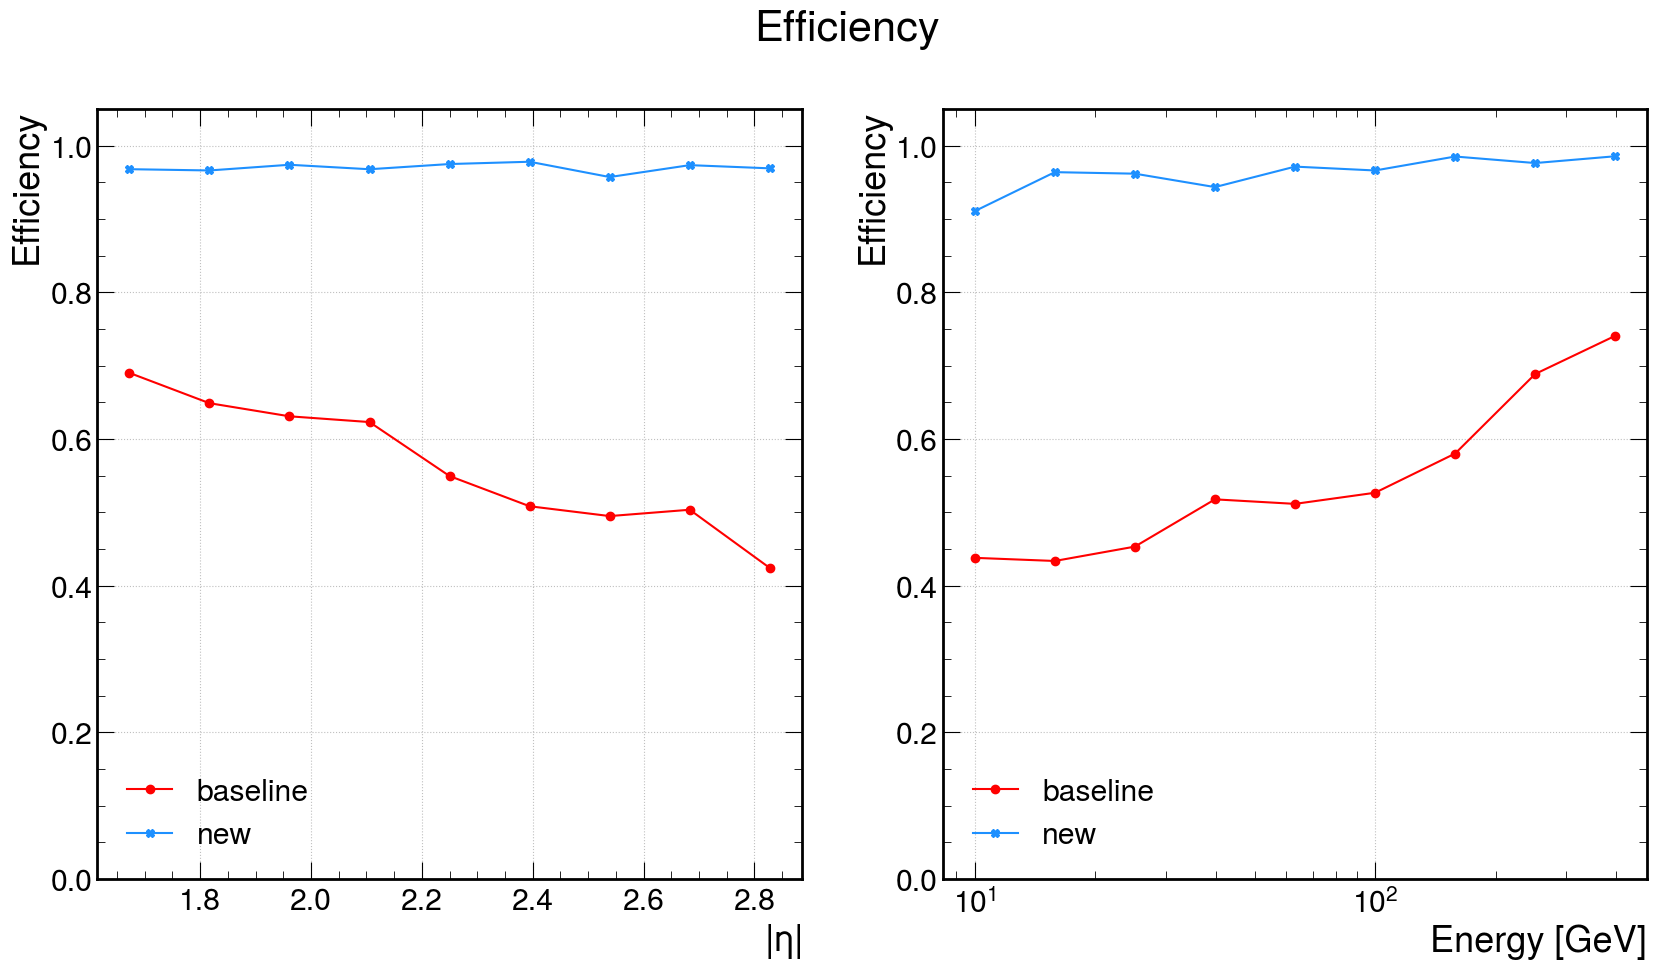

In [64]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effBaseline_eta, marker='o', label = "baseline", color="red")
plt.plot(eta_centers, effLink_eta, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effBaseline_pt, marker='o', label = "baseline", color="red")
plt.semilogx(pt_centers, effLink_pt, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

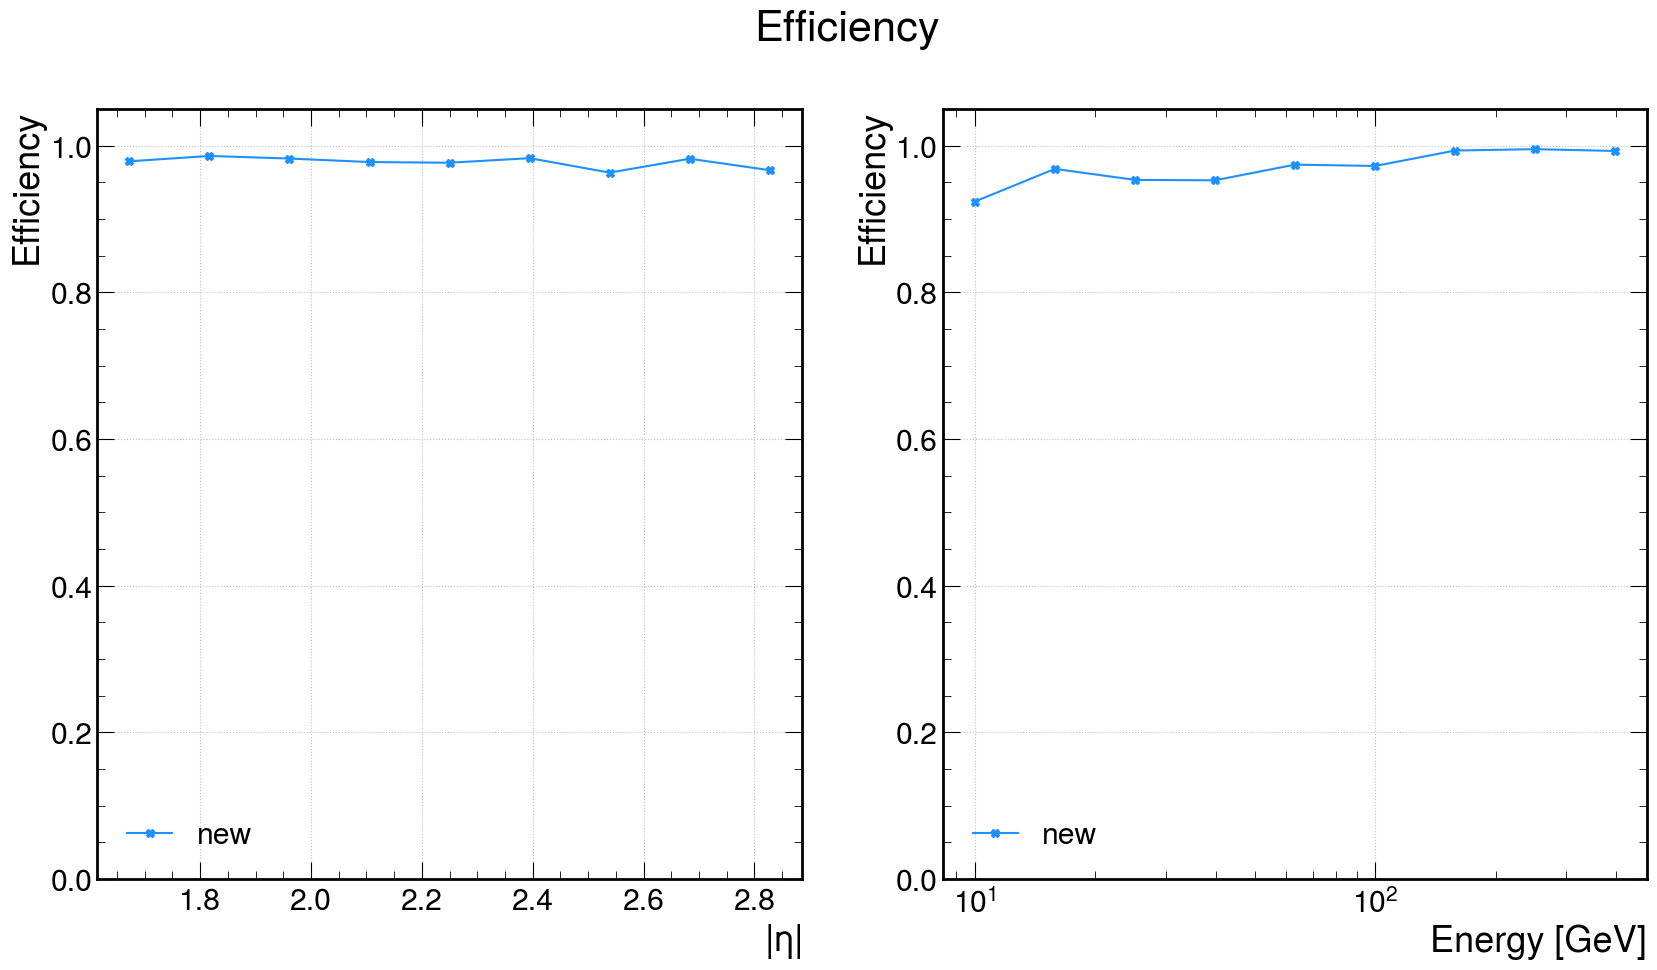

In [52]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
# plt.plot(eta_centers, effBaseline_eta, marker='o', label = "baseline", color="red")
plt.plot(eta_centers, effLink_eta, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
# plt.semilogx(pt_centers, effBaseline_pt, marker='o', label = "baseline", color="red")
plt.semilogx(pt_centers, effLink_pt, marker='X', label = "new", color="dodgerblue")
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

## fake rate

In [35]:
ene_baselineFake = []
eta_baselineFake = []
fake1_baseline =[] # charged vs neutral
fake2_baseline =[] # wrong track

for ev in tqdm(range(len(simtrackstersSC))):
    cands = candidates[ev]
    candTs = candTracksters[ev]
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersSC[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0 or stsSCEv.trackIdx[i][0]==-1:
            continue
        track_to_cp[stsSCEv.trackIdx[i][0]] = stsSCEv.CPidx[i]
    
    for idx in range(len(cands.track_in_candidate)):
        ts_in_cand = cands.tracksters_in_candidate[idx]
        if not (len(ts_in_cand)): continue
        ts_in_cand = ts_in_cand[0]
        tk_in_cand = cands.track_in_candidate[idx]
        
        recoAssScore = associations[ev].ticlCandidate_recoToSim_SC_score[ts_in_cand]
        recoAssEne = associations[ev].ticlCandidate_recoToSim_SC_sharedE[ts_in_cand]
        recoAssIdx = associations[ev].ticlCandidate_recoToSim_SC[ts_in_cand]
        good = np.logical_and(recoAssScore<0.9 , recoAssEne / stsSCEv.raw_energy[recoAssIdx] > 0.5)
        if not np.any(good): continue
        recoAssScore = recoAssScore[good][0]
        recoAssIdx = recoAssIdx[good][0]
        recoAssEne = recoAssEne[good][0]
        
        trkSim = stsSCEv.trackIdx[recoAssIdx]
        if len(trkSim)==0 and tk_in_cand==-1: # true neutral
            fake1_baseline.append(False)
            fake2_baseline.append(False)
        elif len(trkSim)==0 and tk_in_cand!=-1 or len(trkSim)>0 and tk_in_cand==-1:
            # false charged / neutral
            fake1_baseline.append(True)
            fake2_baseline.append(False)
        elif tk_in_cand!=-1 and len(trkSim)>0 :
            if tk_in_cand != trkSim[0]: # true charged but wrong link
                if tk_in_cand in track_to_cp and track_to_cp[tk_in_cand] == track_to_cp[trkSim[0]]: # but same cp so ok
                    fake1_baseline.append(False)
                    fake2_baseline.append(False)
                else: # wrong cp
                    fake1_baseline.append(False)
                    fake2_baseline.append(True)
            else: # true charged and true link
                fake1_baseline.append(False)
                fake2_baseline.append(False)
        else:
            print("I missed sth", tk_in_cand, trkSim)
        
        ene_baselineFake.append(candTs.regressed_energy[ts_in_cand])
        eta_baselineFake.append(candTs.barycenter_eta[ts_in_cand])     

100%|██████████| 1000/1000 [02:10<00:00,  7.65it/s]


In [36]:
eta_baselineFake = np.abs(arr(eta_baselineFake))
ene_baselineFake = arr(ene_baselineFake)
fake1_baseline = arr(fake1_baseline)
fake2_baseline = arr(fake2_baseline)

fake1Baseline_eta = []
fake2Baseline_eta = []
# eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_baselineFake >= eta_bins[i]) & (eta_baselineFake < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        fake1Baseline_eta.append(0)
        fake2Baseline_eta.append(0)
    else:
        fake1Baseline_eta.append(np.mean(fake1_baseline[mask]))
        fake2Baseline_eta.append(np.mean(fake2_baseline[mask]))
#     eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
fake1Baseline_pt = []
fake2Baseline_pt = []
# pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_baselineFake >= pt_bins[i]) & (ene_baselineFake < pt_bins[i+1])

    if np.sum(mask) == 0:
        fake1Baseline_pt.append(0)
        fake2Baseline_pt.append(0)
    else:
        fake1Baseline_pt.append(np.mean(fake1_baseline[mask]))
        fake2Baseline_pt.append(np.mean(fake2_baseline[mask]))
#     pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

In [53]:
ene_fake = []
eta_fake = []
fake1 =[] # charged vs neutral
fake2 =[] # wrong track

for ev in tqdm(range(len(simtrackstersSC))):
    tracksEv = tracks[ev]
    stsSCEv = simtrackstersSC[ev]
    
    track_to_cp = {}
    for i in range(len(stsSCEv.trackIdx)):
        if len(stsSCEv.trackIdx[i]) == 0 or stsSCEv.trackIdx[i][0]==-1:
            continue
        track_to_cp[stsSCEv.trackIdx[i][0]] = stsSCEv.CPidx[i]
    
    # loop over links_ev
    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1]
    for link in links_ev:
        ts_in_cand = link['tracksters'] # reco ts
        tk_in_cand = link['track'] # reco trk
        if len(ts_in_cand)==0: continue
            
        # sim
        trkSim = ak.flatten(stsSCEv.trackIdx[ts_in_cand])
        
        if len(trkSim)==0 and tk_in_cand==None: # true neutral
            fake1.append(False)
            fake2.append(False)
        elif len(trkSim)==0 and tk_in_cand!=None or len(trkSim)>0 and tk_in_cand==None:
            # false charged / neutral
            fake1.append(True)
            fake2.append(False)
        elif tk_in_cand!=None and len(trkSim)>0 :                
            if tk_in_cand not in trkSim: # true charged but wrong link
                true_cp = [track_to_cp[tk] for tk in trkSim]
                if tk_in_cand in track_to_cp and track_to_cp[tk_in_cand] in true_cp: # but same cp so ok
                    fake1.append(False)
                    fake2.append(False)
                else: # wrong cp
                    fake1.append(False)
                    fake2.append(True)
            else: # true charged and true link
                fake1.append(False)
                fake2.append(False)
        else:
            print("I missed sth", tk_in_cand, trkSim)
        
        ene_fake.append(sum(stsSCEv.raw_energy[ts_in_cand]))
        eta_fake.append(np.mean(stsSCEv.barycenter_eta[ts_in_cand]))     

100%|██████████| 1000/1000 [02:21<00:00,  7.09it/s]


In [54]:
eta_fake = np.abs(arr(eta_fake))
ene_fake = arr(ene_fake)
fake1 = arr(fake1)
fake2 = arr(fake2)

fake1_eta = []
fake2_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_fake >= eta_bins[i]) & (eta_fake < eta_bins[i+1])
    
    if np.sum(mask) == 0:
        fake1_eta.append(0)
        fake2_eta.append(0)
    else:
        fake1_eta.append(np.mean(fake1[mask]))
        fake2_eta.append(np.mean(fake2[mask]))
    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))
    
fake1_pt = []
fake2_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (ene_fake >= pt_bins[i]) & (ene_fake < pt_bins[i+1])

    if np.sum(mask) == 0:
        fake1_pt.append(0)
        fake2_pt.append(0)
    else:
        fake1_pt.append(np.mean(fake1[mask]))
        fake2_pt.append(np.mean(fake2[mask]))
    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

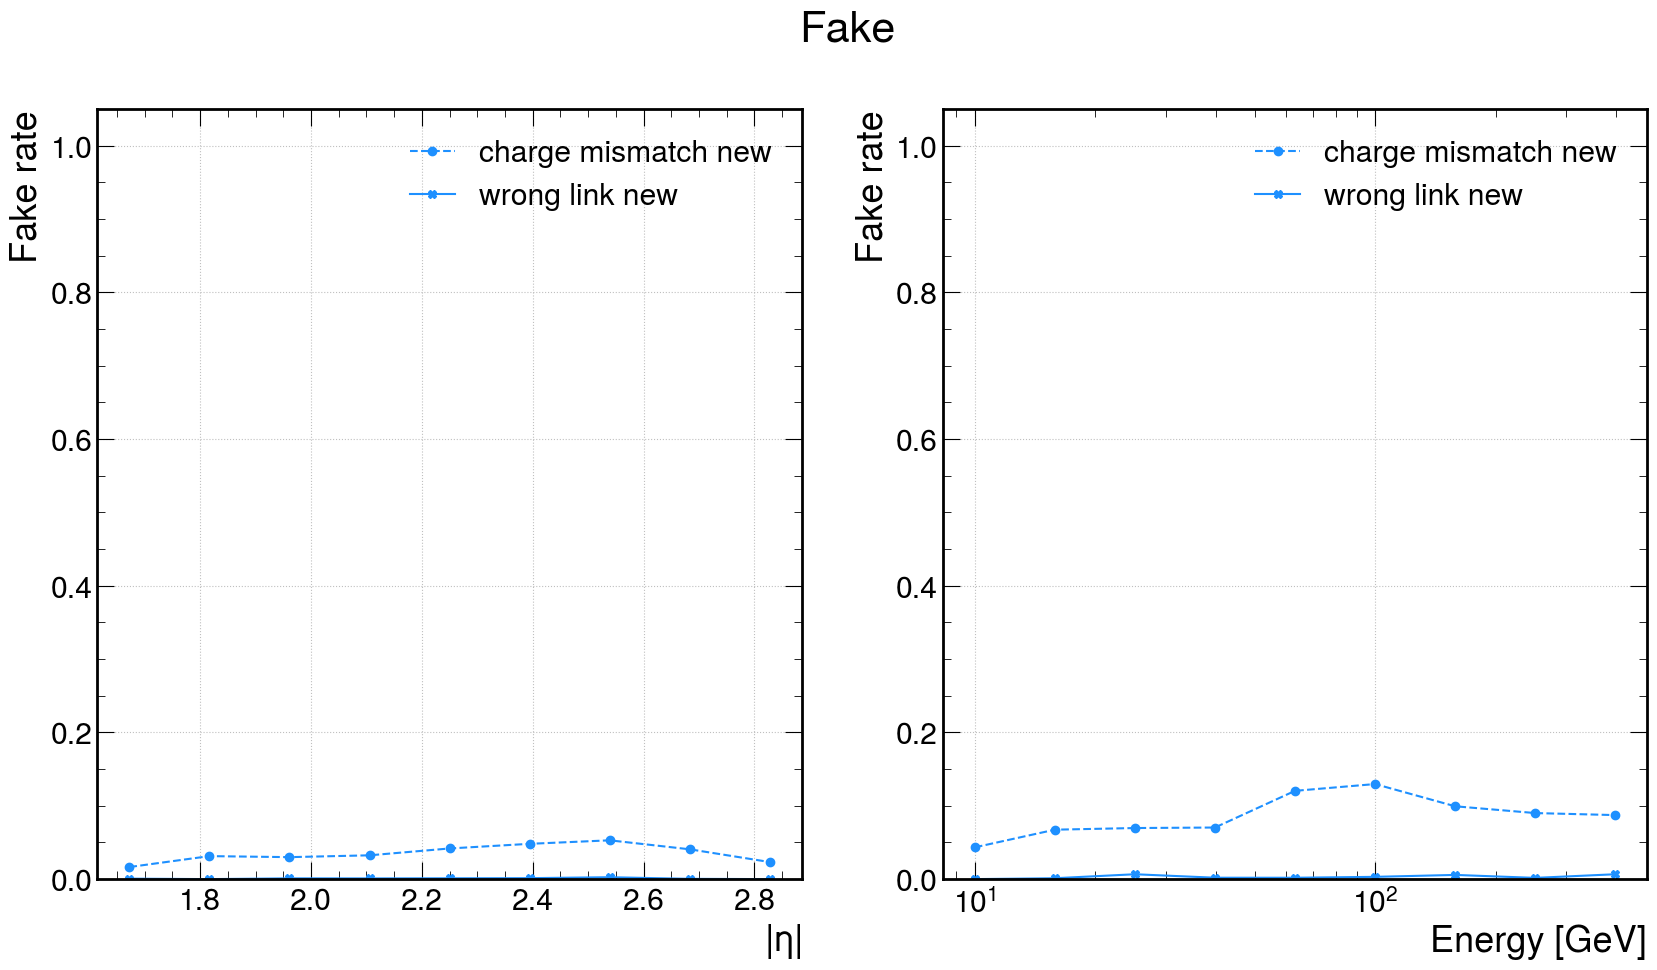

In [55]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Fake")
plt.subplot(1, 2, 1)
# plt.plot(eta_centers, fake1Baseline_eta, marker='o', linestyle="--", label = "charge mismatch", color="red")
# plt.plot(eta_centers, fake2Baseline_eta, marker='X', label = "wrong link", color="red") #dodgerblue
plt.plot(eta_centers, fake1_eta, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.plot(eta_centers, fake2_eta, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
# plt.semilogx(pt_centers, fake1Baseline_pt, marker='o', linestyle="--", label = "charge mismatch", color="red")
# plt.semilogx(pt_centers, fake2Baseline_pt, marker='X', label = "wrong link", color="red") #dodgerblue
plt.semilogx(pt_centers, fake1_pt, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.semilogx(pt_centers, fake2_pt, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

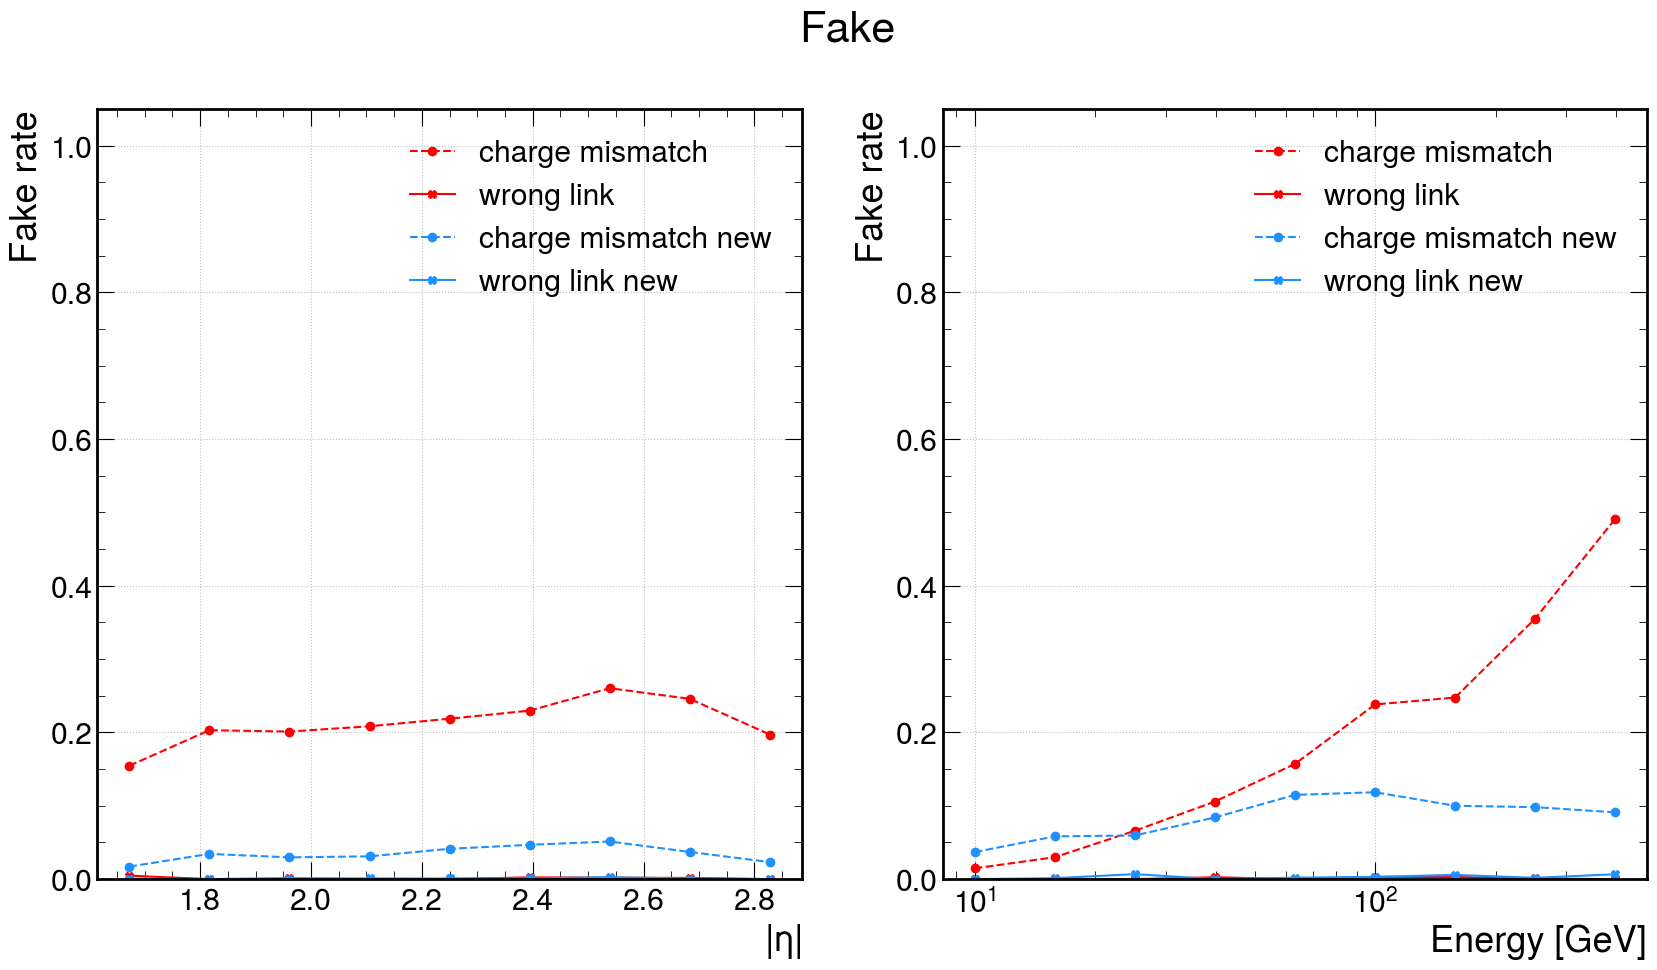

In [67]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Fake")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, fake1Baseline_eta, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.plot(eta_centers, fake2Baseline_eta, marker='X', label = "wrong link", color="red") #dodgerblue
plt.plot(eta_centers, fake1_eta, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.plot(eta_centers, fake2_eta, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, fake1Baseline_pt, marker='o', linestyle="--", label = "charge mismatch", color="red")
plt.semilogx(pt_centers, fake2Baseline_pt, marker='X', label = "wrong link", color="red") #dodgerblue
plt.semilogx(pt_centers, fake1_pt, marker='o', linestyle="--", label = "charge mismatch new", color="dodgerblue")
plt.semilogx(pt_centers, fake2_pt, marker='X', label = "wrong link new", color="dodgerblue") #dodgerblue
plt.legend()
plt.xlabel(r'Energy [GeV]')
plt.ylabel('Fake rate')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

# True graph

In [36]:
import networkx as nx

def add_ts_node(G, ts, tsLinksEv):
    ts_node = f"ts_{ts}"
    if ts_node not in G:
        G.add_node(
            ts_node,
            node_type="trackster",
            eta=tsLinksEv.barycenter_eta[ts],
            z=tsLinksEv.barycenter_z[ts],
            phi=tsLinksEv.barycenter_phi[ts]                    
        )
#         print("add ts node", ts)

def build_truth_graph(true_links_ev, tracksEv, tsLinksEv):
    g_truth = nx.Graph()

    for entry in true_links_ev:
        reco_ts_ids = entry["reco_ts"]
        track_ids   = entry["track_id"]  # list or None
             
        # ---- charged case: link to tracks
        if track_ids is not None:
            for trk in track_ids:
                trk_node = f"trk_{trk}"
                if trk_node not in g_truth:
                    trk_pos = find_track_id(tracksEv.track_id, trk)
                    g_truth.add_node(
                        trk_node,
                        node_type="track",
                        eta=tracksEv.track_hgcal_eta[trk_pos],
                        phi=tracksEv.track_hgcal_phi[trk_pos]       
                    )
#                     print("add track node", trk)
                #print(reco_ts_ids, tsLinksEv.barycenter_z[reco_ts_ids], np.argmin(np.abs(tsLinksEv.barycenter_z[reco_ts_ids])))
                for ts in reco_ts_ids:
                    add_ts_node(g_truth, ts, tsLinksEv)
                    g_truth.add_edge(trk_node, f"ts_{ts}")
#                     print("add edge", trk_node, f"ts_{ts}")

        # ---- neutral case: connect reco TS among themselves (same CP)
        else:
            for i in range(len(reco_ts_ids)):
                add_ts_node(g_truth, reco_ts_ids[i], tsLinksEv)
                for j in range(i+1, len(reco_ts_ids)):
                    add_ts_node(g_truth, reco_ts_ids[j], tsLinksEv)
                    g_truth.add_edge(
                        f"ts_{reco_ts_ids[i]}",
                        f"ts_{reco_ts_ids[j]}"
                    )
#                     print("add edge", reco_ts_ids[i], reco_ts_ids[j])
                    

    return g_truth

In [252]:
true_links = []
true_links_extra = []
graph_event = []
debug=True

for ev in tqdm(prange(len(simtrackstersSC))):
    assEv    = associations[ev]
    stsSCEv   = simtrackstersSC[ev]
    stsCPEv   = simtrackstersCP[ev]
    tracksEv = tracks[ev]
    tsLinksEv = tracksterLinks[ev]

    true_links_ev = []
    true_links_extra_ev = []
    
    trk_only_in_cp = np.setdiff1d(ak.flatten(stsCPEv.trackIdx), ak.flatten(stsSCEv.trackIdx))
    
    for idx in prange(len(stsSCEv.trackIdx)):
        # charged / neutral identification
        trk_id = find_track_id(tracksEv.track_id, stsSCEv.trackIdx[idx])
        is_charged = trk_id != -1
        
        # select good reco tracksters
        maskScore = assEv.ticlTracksterLinks_simToReco_SC_score[idx] < 0.99 # FIXME tracksters with score 0.997 but shEnergy very high
        assocRecoTsIds = assEv.ticlTracksterLinks_simToReco_SC[idx]
        tsEnergy = tsLinksEv.raw_energy[assocRecoTsIds]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_SC_sharedE[idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.5
        maskIdx = maskScore & maskEnergy
        assIndices = assocRecoTsIds[maskIdx]
        
        if len(assIndices)==0: continue
            
        sortTs = np.argsort(np.abs(tsLinksEv.barycenter_z[assIndices]))
        assIndices = assIndices[sortTs]

        # ---- store truth info
        true_links_ev.append({
            "cp_id": stsSCEv.CPidx[idx],
            "track_id": [int(trkIdx) for trkIdx in stsSCEv.trackIdx[idx]] if is_charged else None,
#             "is_charged": is_charged,
            "reco_ts": [int(assIdx) for assIdx in assIndices]
        })
        
    # check for tracks that are only in simtrackstersCP
    for trk_idx in trk_only_in_cp:
        stsCP_idx = ak.where(ak.any(stsCPEv.trackIdx == trk_idx, axis=1))[0][0]
        # charged / neutral identification
        trk_pos_in_coll = find_track_id(tracksEv.track_id, trk_idx)
        is_charged = trk_pos_in_coll != -1
        
        # select good reco tracksters
        maskScore = assEv.ticlTracksterLinks_simToReco_CP_score[stsCP_idx] < 1 # FIXME tracksters with score 0.997 but shEnergy very high
        assocRecoTsIds = assEv.ticlTracksterLinks_simToReco_CP[stsCP_idx]
        tsEnergy = tsLinksEv.raw_energy[assocRecoTsIds]
        sharedEnergy = assEv.ticlTracksterLinks_simToReco_CP_sharedE[stsCP_idx]
        maskEnergy = sharedEnergy / tsEnergy > 0.6
        maskIdx = maskScore & maskEnergy
        assIndices = assocRecoTsIds[maskIdx]
        
        if len(assIndices)==0: continue
            
        sortTs = np.argsort(np.abs(tsLinksEv.barycenter_z[assIndices]))
        assIndices = assIndices[sortTs]
        
        # ---- store truth info
        true_links_extra_ev.append({
            "cp_id": stsCPEv.CPidx[stsCP_idx],
            "track_id": [int(trkIdx) for trkIdx in stsCPEv.trackIdx[stsCP_idx]] if is_charged else None,
#             "is_charged": is_charged,
            "reco_ts": [int(assIdx) for assIdx in assIndices]
        })

    true_links.append(true_links_ev)
    true_links_extra.append(true_links_extra_ev)
    if debug:
        graph_event.append(build_truth_graph(true_links_ev, tracksEv, tsLinksEv))

100%|██████████| 1000/1000 [02:43<00:00,  6.10it/s]


In [96]:
true_links

[[{'cp_id': np.int32(0), 'track_id': [2], 'reco_ts': [5, 7, 3]},
  {'cp_id': np.int32(1), 'track_id': [3], 'reco_ts': [1]},
  {'cp_id': np.int32(2), 'track_id': None, 'reco_ts': [2]},
  {'cp_id': np.int32(3), 'track_id': [1], 'reco_ts': [6]},
  {'cp_id': np.int32(4), 'track_id': [0], 'reco_ts': [0]},
  {'cp_id': np.int32(5), 'track_id': None, 'reco_ts': [4]}],
 [{'cp_id': np.int32(0), 'track_id': [3], 'reco_ts': [1]},
  {'cp_id': np.int32(1), 'track_id': [1], 'reco_ts': [2]},
  {'cp_id': np.int32(2), 'track_id': None, 'reco_ts': [3]},
  {'cp_id': np.int32(3), 'track_id': [2], 'reco_ts': [5]},
  {'cp_id': np.int32(4), 'track_id': [0], 'reco_ts': [4, 6]},
  {'cp_id': np.int32(5), 'track_id': None, 'reco_ts': [0, 7]}],
 [{'cp_id': np.int32(0), 'track_id': [1], 'reco_ts': [3, 1]},
  {'cp_id': np.int32(1), 'track_id': [0], 'reco_ts': [10, 0]},
  {'cp_id': np.int32(2), 'track_id': None, 'reco_ts': [2, 12, 8]},
  {'cp_id': np.int32(3), 'track_id': [3], 'reco_ts': [4]},
  {'cp_id': np.int32(4)

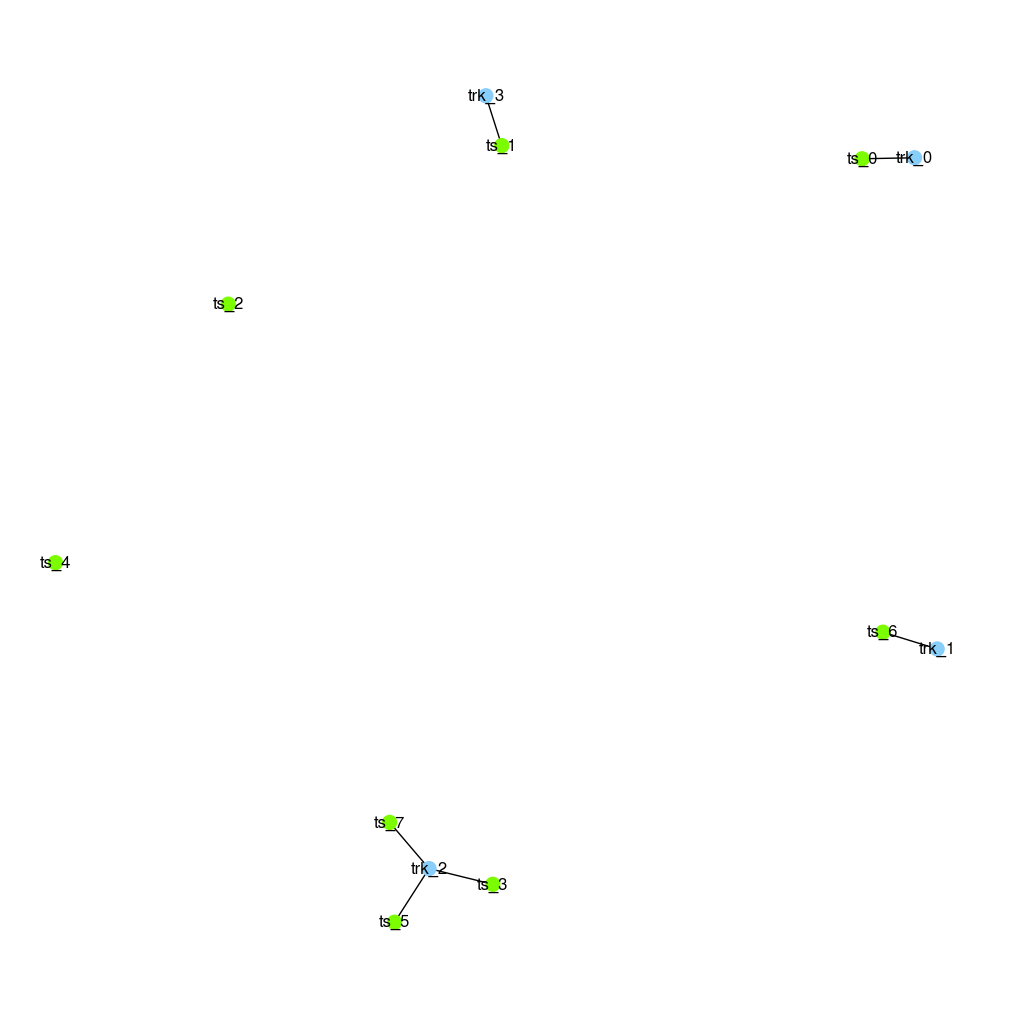

In [86]:
g0Truth = graph_event[0]
color_map = {
    "SRC": "red",
    "track": "lightskyblue",
    "trackster": "lawngreen",
    "SNK": "gray"
}

node_colors = [
    color_map[g0Truth.nodes[n]["node_type"]] for n in g0Truth.nodes()
]

nx.draw(g0Truth, node_color=node_colors, with_labels=True, node_size=100)

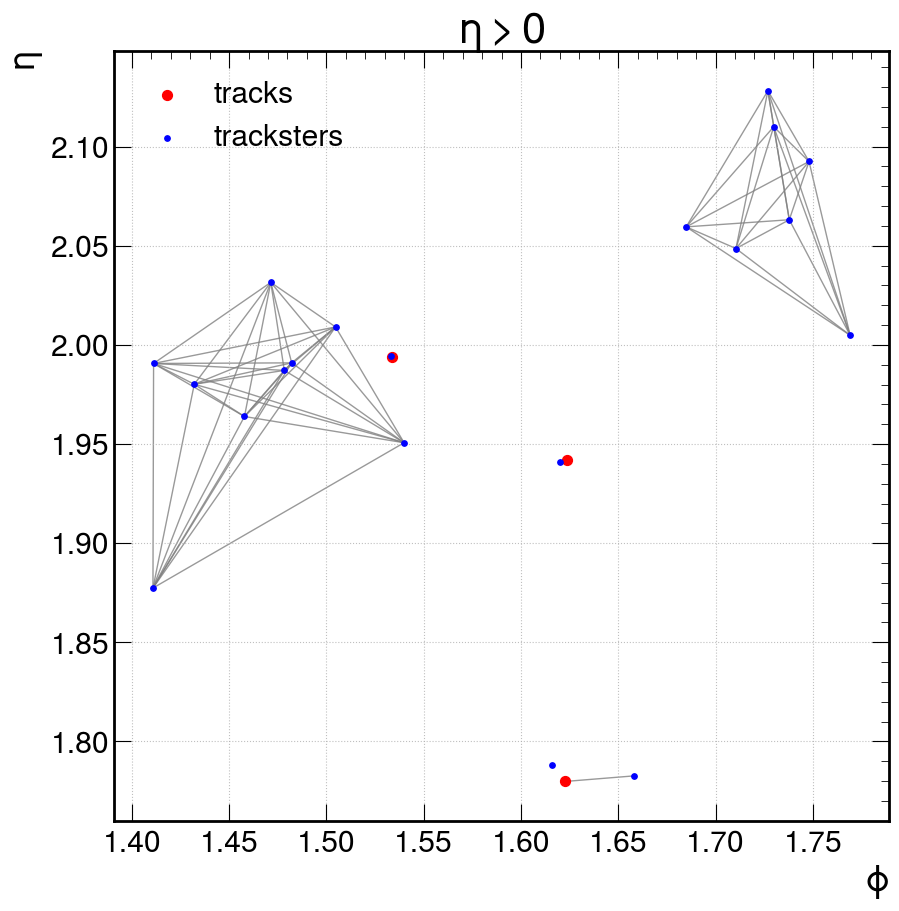

In [358]:
# Build positions
pos = {
    n: (d["phi"], d["eta"])
    for n, d in g0Truth.nodes(data=True)
    if "phi" in d and "eta" in d
}

# Split nodes by type and eta sign
trk_pos = [n for n, d in g0Truth.nodes(data=True) if d["node_type"]=="track"]
ts_pos  = [n for n, d in g0Truth.nodes(data=True) if d["node_type"]=="trackster"]

etas = [v[1] for v in pos.values()]
phis = [v[0] for v in pos.values()]
phi_min, phi_max = min(phis), max(phis)
eta_min, eta_max = min(etas), max(etas)

plt.figure()
ax1 = plt.subplot(1,1,1)
nx.draw_networkx_nodes(g0Truth, pos, nodelist=trk_pos, node_color="red", node_size=50, ax=ax1, label="tracks")
nx.draw_networkx_nodes(g0Truth, pos, nodelist=ts_pos, node_color="blue", node_size=15, ax=ax1, label="tracksters")
nx.draw_networkx_edges(g0Truth, pos, edgelist=[e for e in g0Truth.edges], # if e[0] in trk_pos or e[1] in ts_pos],
                       edge_color="gray", alpha=0.8, ax=ax1, width=1, arrows=False)

ax1.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
ax1.set_xlim(phi_min- 0.02, phi_max+0.02)
ax1.set_ylim(eta_min- 0.02, eta_max+0.02)
# ax1.set_xticks(np.linspace(phi_min, phi_max, 4))
# #ax1.set_xticklabels([r"$-\pi$", r"$-\pi/2$", "0", r"$\pi/2$", r"$\pi$"])
# ax1.set_yticks(np.linspace(eta_min, eta_max, 4))
ax1.set_xlabel(r"$\phi$")
ax1.set_ylabel(r"$\eta$")
ax1.set_title(r"$\eta > 0$")
ax1.legend()
ax1.grid(True)
plt.show()

In [45]:
def pretty_print(links):
    string = ""
    for l in links:
        string += "\n- track: "+ str(l['track_id']) + ", tracksters: "+ str(l['reco_ts'])+", CP: " + str(l['cp_id'])
    return string

In [ ]:
for ev in range(len(true_links)):
    print(f"\n--- ev {ev} ---")
    print("true_links: ", pretty_print(true_links[ev]))
    true_tracks = np.array([l['track_id'] for l in true_links[ev] if l['track_id'] is not None ]).flatten()
    print("true_links extra: ", pretty_print(true_links_extra[ev]))
    true_tracks_extra = np.array([l['track_id'] for l in true_links[ev] if l['track_id'] is not None ]).flatten()
    
    print("reco:")
    for endcap in [all_candidates[2*ev], all_candidates[2*ev+1]]:
        for cand in endcap:
            if cand['track'] is None:
                print("- neutral: ", cand["tracksters"])
            else: #if cand['track'] in true_tracks or cand['track'] in true_tracks_extra: #uncomment this if running with PU
                print("- charged: ", cand)

In [25]:
# # check that tracksters are used only once
# for c_ev in all_candidates:
#     all_ts = []
#     for c in c_ev:
#         all_ts.extend(c["tracksters"])
#     assert(len(all_ts) == len(set(all_ts)))

# full validation new

In [405]:
effTight_flags = []
effLoose_flags = []
purity_flags = []
eta_vals = []
pt_vals = []

wrong = []
for ev in prange(len(true_links)):

    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1] #all_links_no_score[ev]
    tracks_links_ev = np.array([l['track'] if l['track'] is not None else -1 for l in links_ev])
    tracksEv = tracks[ev]
    for true_link in true_links[ev]:
        itrk = true_link['track_id']
        true_ts_list = true_link['reco_ts']
        if not len(true_ts_list) or itrk is None: continue #only charged for now
        trk_pos = find_track_id(tracksEv.track_id, itrk) 
        if trk_pos == -1:
            continue
        
        # Track kinematics
        eta = tracksEv.track_hgcal_eta[trk_pos]
        pt  = tracksEv.track_hgcal_pt[trk_pos]
        p  = tracksEv.track_p[trk_pos]
        
        if pt < 1 or p < 2: continue
        
        # Was this track linked at all?
        if itrk[0] not in tracks_links_ev: 
            effTight_flags.append(False)
            effLoose_flags.append(False)
            purity_flags.append(False)
            eta_vals.append(eta)
            pt_vals.append(pt)
            wrong.append((ev, itrk))
            continue
            
        cand_pos = np.where(np.array(tracks_links_ev)==itrk[0])[0][0]
        reco_ts = links_ev[cand_pos]['tracksters']
        
        # True if ANY true trackster is found
        matched_loose = any(its in reco_ts for its in true_ts_list)
        matched_tight = all(its in reco_ts for its in true_ts_list)
        pure = all(its in true_ts_list for its in reco_ts)
        
        if matched_loose==False:
            wrong.append((ev, itrk))
        
        effTight_flags.append(matched_tight)
        effLoose_flags.append(matched_loose)
        purity_flags.append(pure)
        eta_vals.append(eta)
        pt_vals.append(pt)
    
# print(effTight_flags)
effTight_flags = arr(effTight_flags)
effLoose_flags = arr(effLoose_flags)
purity_flags = arr(purity_flags)
eta_vals = arr(eta_vals)
pt_vals = arr(pt_vals)

In [28]:
effTight = np.mean(arr(effTight_flags))                                                                                                                                                      
effLoose = np.mean(arr(effLoose_flags))
purity = np.mean(arr(purity_flags))

print(str(PT) + " " + str(ETA) + " " + str(effTight) + " " + str(effLoose) + " " + str(purity))

100 1.7 0.46269063180827885 0.8970588235294118 0.8537581699346405


In [57]:
eta_bins = np.linspace(1.6, 2.9 ,10)

eta_vals = np.abs(np.array(eta_vals))

effTight_eta = []
effLoose_eta = []
purity_eta = []
eta_centers = []

for i in range(len(eta_bins) - 1):
    mask = (eta_vals >= eta_bins[i]) & (eta_vals < eta_bins[i+1])

    if np.sum(mask) == 0:
        effTight_eta.append(0)
        effLoose_eta.append(0)
        purity_eta.append(0)
    else:
        effTight_eta.append(np.mean(effTight_flags[mask]))
        effLoose_eta.append(np.mean(effLoose_flags[mask]))
        purity_eta.append(np.mean(purity_flags[mask]))

    eta_centers.append(0.5 * (eta_bins[i] + eta_bins[i+1]))

In [58]:
pt_bins = np.linspace(1, 100 ,10)

pt_vals = np.array(pt_vals)

effTight_pt = []
effLoose_pt = []
purity_pt = []
pt_centers = []

for i in range(len(pt_bins) - 1):
    mask = (pt_vals >= pt_bins[i]) & (pt_vals < pt_bins[i+1])

    if np.sum(mask) == 0:
        effTight_pt.append(0)
        effLoose_pt.append(0)
        purity_pt.append(0)
    else:
        effTight_pt.append(np.mean(effTight_flags[mask]))
        effLoose_pt.append(np.mean(effLoose_flags[mask]))
        purity_pt.append(np.mean(purity_flags[mask]))

    pt_centers.append(np.sqrt(pt_bins[i] * pt_bins[i+1]))

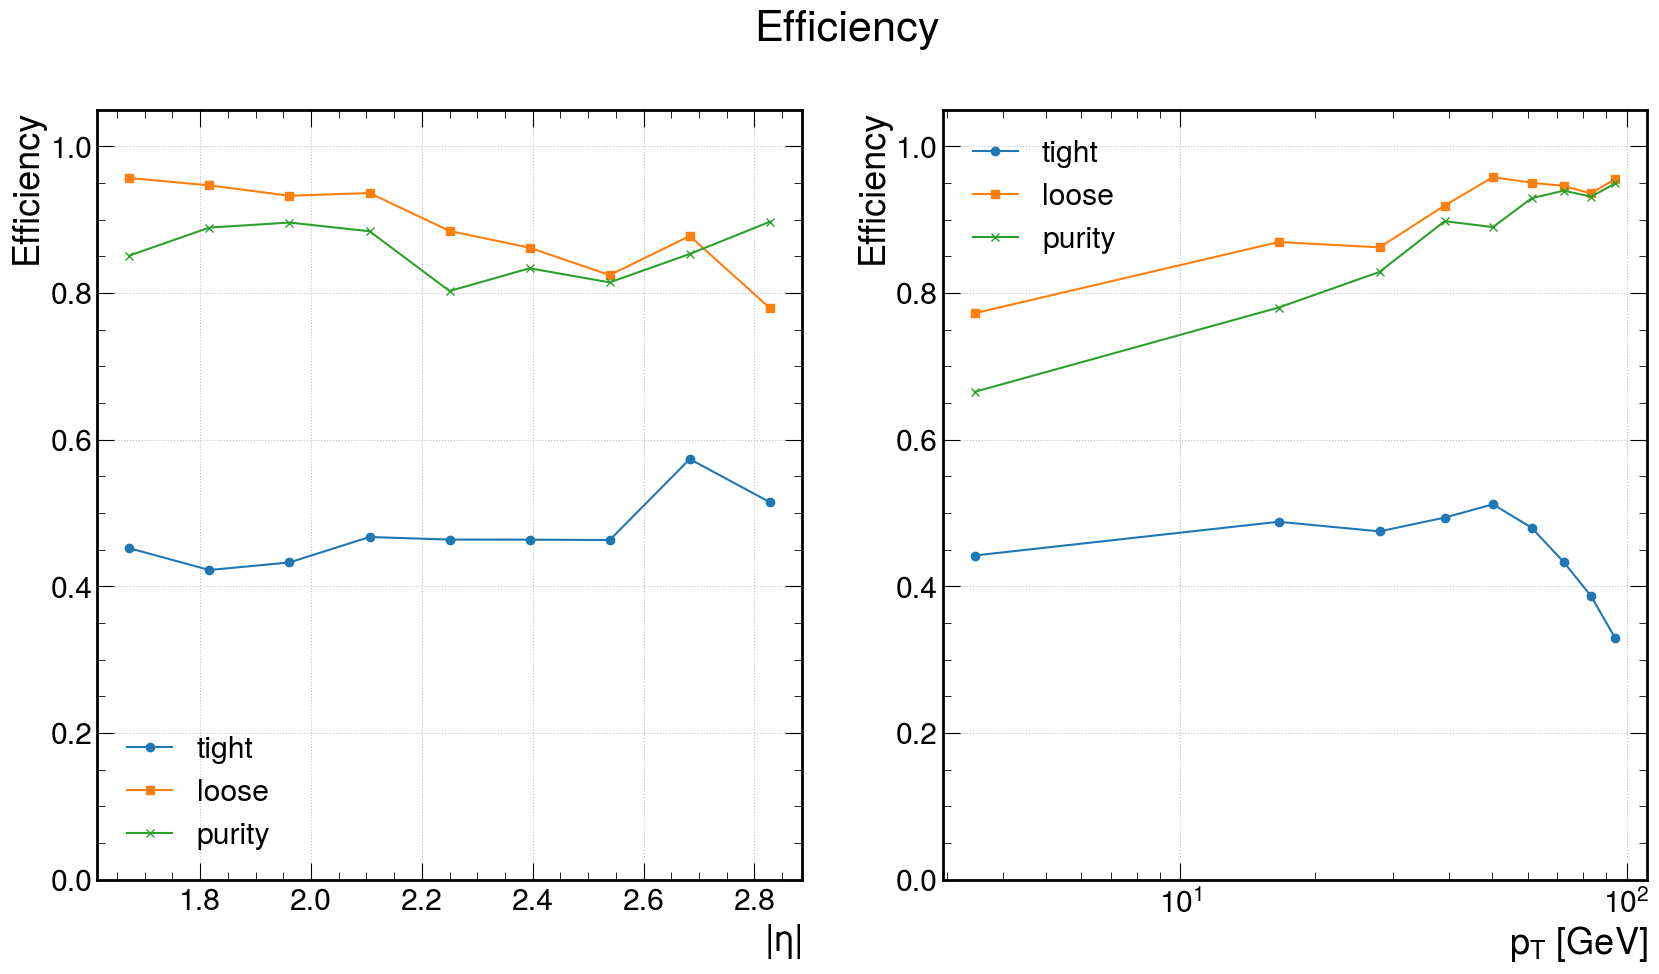

In [34]:
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effTight_eta, marker='o', label = "tight")
plt.plot(eta_centers, effLoose_eta, marker='s', label = "loose")
plt.plot(eta_centers, purity_eta, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effTight_pt, marker='o', label = "tight")
plt.semilogx(pt_centers, effLoose_pt, marker='s', label = "loose")
plt.semilogx(pt_centers, purity_pt, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

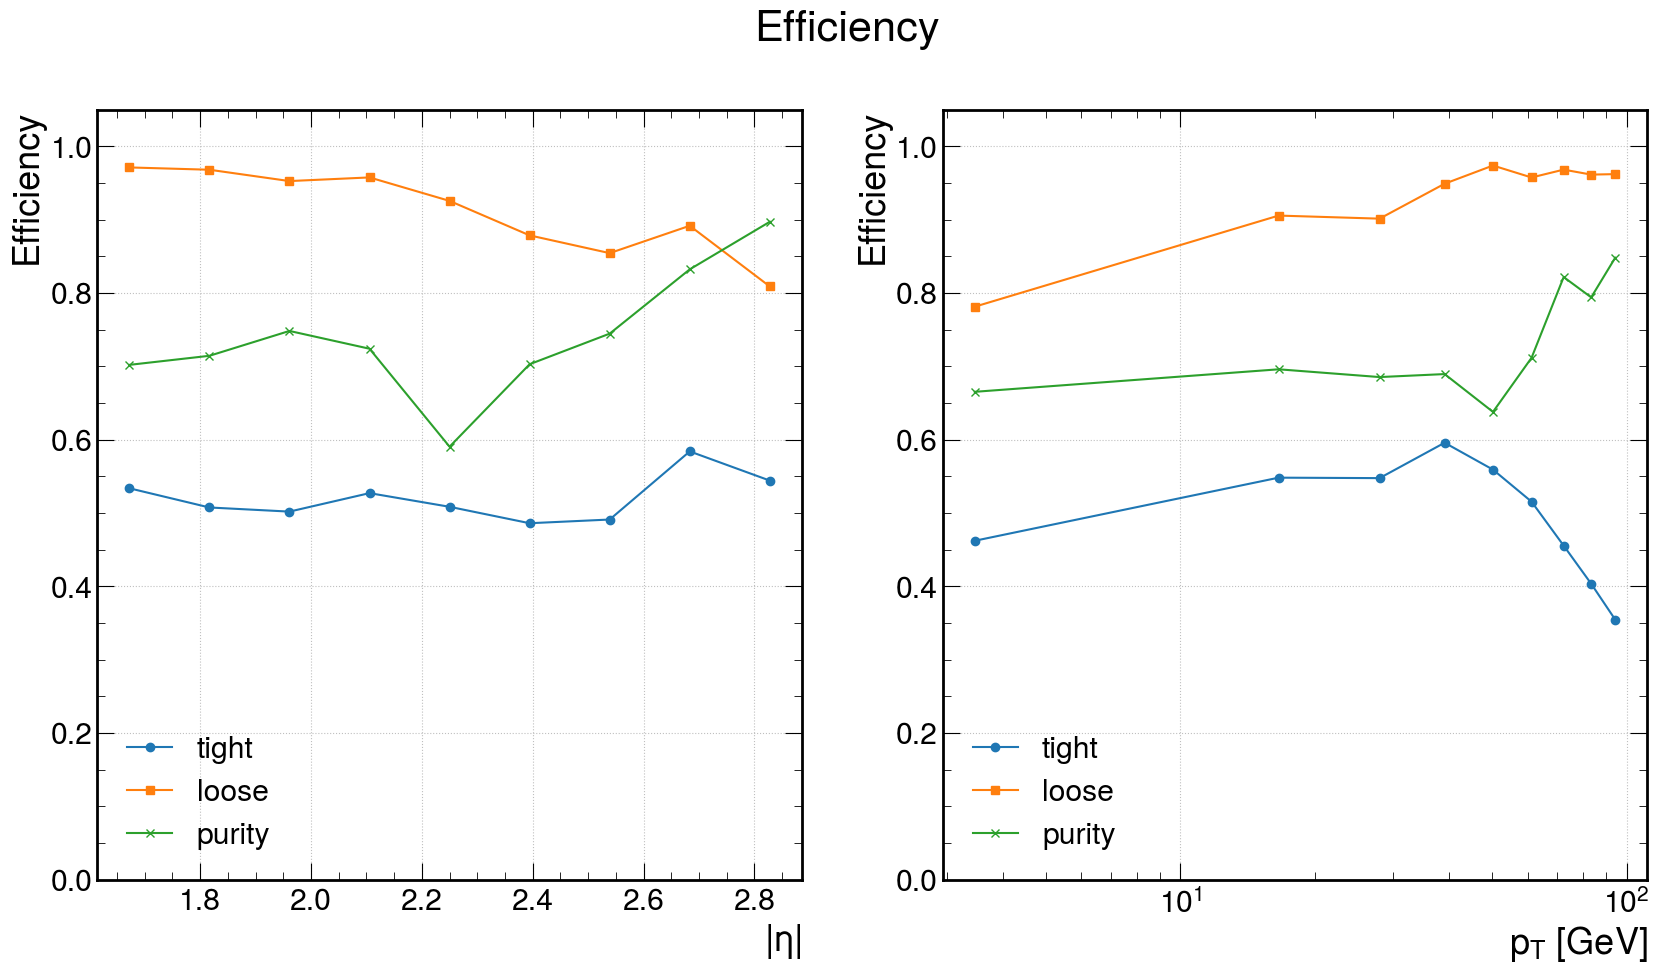

In [239]:
#dR=0.1
plt.style.use(hep.style.CMS)

plt.figure(figsize=(20, 10))
plt.suptitle("Efficiency")
plt.subplot(1, 2, 1)
plt.plot(eta_centers, effTight_eta, marker='o', label = "tight")
plt.plot(eta_centers, effLoose_eta, marker='s', label = "loose")
plt.plot(eta_centers, purity_eta, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$|\eta|$')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()

plt.subplot(1, 2, 2)
plt.semilogx(pt_centers, effTight_pt, marker='o', label = "tight")
plt.semilogx(pt_centers, effLoose_pt, marker='s', label = "loose")
plt.semilogx(pt_centers, purity_pt, marker='x', label = "purity")
plt.legend()
plt.xlabel(r'$p_T$ [GeV]')
plt.ylabel('Efficiency')
plt.ylim(0, 1.05)
plt.grid()
plt.show()

## debug missing links

In [49]:
def debug_missing_links_flow(ev, trk_id):
    #trk_id = trk_id[0]
    # find the tuple for this track
    correct_ts_ids = None
    for true_link in true_links[ev]:
        tid = true_link['track_id'][0] if true_link['track_id'] is not None else -1 
        ts_arr = true_link['reco_ts']
        cp_id = true_link['cp_id']
        if tid == trk_id:
            correct_ts_ids = np.asarray(ts_arr)  # convert Awkward Array to numpy
            break

    if correct_ts_ids is None:
        print(f"TYPE 1: Track {trk_id} not found in true_links for event {ev}")
        return

    links_ev = all_candidates[2*ev] + all_candidates[2*ev+1]
    ts_links_ev = []
    for l in links_ev:
        ts_links_ev.append(l['tracksters'])

    print(f"\nEvent {ev}, track {trk_id}")
    print(f"Correct TS IDs: {correct_ts_ids}")

    for correct_ts in correct_ts_ids:
        if correct_ts not in ak.flatten(ts_links_ev):
            print(f"  Correct TS {correct_ts} not linked to anything nor neutral")
            continue

        # check if linked elsewhere
        try:
            cand_idx = ak.where(ak.sum(ak.Array(ts_links_ev)==correct_ts, axis=1)==1)[0][0]
        except:
            print(f"    TYPE 2: Correct TS {correct_ts} not linked")
            print(ts_links_ev, correct_ts)
            continue

        tk_linked = links_ev[cand_idx]['track']
        if tk_linked==trk_id:
            print("    TS {correct_ts} linked correctly")
            continue
        elif tk_linked==None:
            print(f"    TYPE 3: Correct TS {correct_ts} not linked to a track")
            continue
        else:
            print(f"    TYPE 4: Correct TS {correct_ts} wrongly linked to track {tk_linked}")

        # get pT/P for correct and wrongly linked tracks
#         print(tracks[ev].track_id, trk_id)
        pos_correct = np.where(tracks[ev].track_id == trk_id)[0][0]
        Pt_correct = tracks[ev].track_hgcal_pt[pos_correct]
        P_correct = tracks[ev].track_p[pos_correct]

        pos_wrong = np.where(tracks[ev].track_id == tk_linked)[0][0]
        Pt_wrong = tracks[ev].track_hgcal_pt[pos_wrong]
        P_wrong = tracks[ev].track_p[pos_wrong]

        print(f"      Correct track Pt: {Pt_correct:.3f}, Wrongly linked track Pt: {Pt_wrong:.3f}")
        
        for true_link in true_links[ev]:
            tid_wrong = true_link['track_id'][0] if true_link['track_id'] is not None else -1 
            cp_id_wrong = true_link['cp_id']
            if tid_wrong == tk_linked:
                print(f"      Correct track CP: {cp_id}, Wrongly linked track CP: {cp_id_wrong}")
                break

In [50]:
# example: check ev=19, track 4017
for ev, trk in wrong:
    debug_missing_links_flow(ev=ev, trk_id=trk)


Event 1, track 0
Correct TS IDs: [0]
    TYPE 3: Correct TS 0 not linked to a track

Event 7, track 0
Correct TS IDs: [0]
    TYPE 4: Correct TS 0 wrongly linked to track 1
      Correct track Pt: 10.555, Wrongly linked track Pt: 9.731
      Correct track CP: 1, Wrongly linked track CP: 2

Event 12, track 3
Correct TS IDs: [0]
    TYPE 3: Correct TS 0 not linked to a track

Event 16, track 1
Correct TS IDs: [ 0 11]
    TYPE 3: Correct TS 0 not linked to a track
    TYPE 3: Correct TS 11 not linked to a track

Event 17, track 1
Correct TS IDs: [ 0 16 18]
    TYPE 4: Correct TS 0 wrongly linked to track 0
      Correct track Pt: 9.261, Wrongly linked track Pt: 14.849
      Correct track CP: 2, Wrongly linked track CP: 5
    TYPE 4: Correct TS 16 wrongly linked to track 0
      Correct track Pt: 9.261, Wrongly linked track Pt: 14.849
      Correct track CP: 2, Wrongly linked track CP: 5
    TYPE 3: Correct TS 18 not linked to a track

Event 17, track 0
Correct TS IDs: [17]
    TYPE 3: Co

IndexError: list index out of range